In [1]:
pwd()

'C:\\Users\\Aniket\\OneDrive\\문서\\sem3\\Thesis'

In [2]:
cd "D:\\NCI Docs\\NCI LECS\\Sem 3\\Project"

D:\NCI Docs\NCI LECS\Sem 3\Project


In [3]:
ls

 Volume in drive D is New Volume
 Volume Serial Number is D861-AED0

 Directory of D:\NCI Docs\NCI LECS\Sem 3\Project

04-12-2025  23:54    <DIR>          .
06-12-2025  15:49    <DIR>          ..
05-12-2025  23:08    <DIR>          .idea
13-09-2025  17:01    <DIR>          .ipynb_checkpoints
21-11-2025  19:41       511,980,631 cached_embeddings.pt
21-11-2025  18:49    <DIR>          dataset
05-12-2025  12:11    <DIR>          models
05-12-2025  12:10         2,608,090 plot2.png
09-10-2025  15:14               250 requirements.txt
22-11-2025  21:10    <DIR>          runs
13-09-2025  17:03             1,169 sample.ipynb
18-11-2025  17:34            27,930 sample.py
               5 File(s)    514,618,070 bytes
               7 Dir(s)  418,268,258,304 bytes free


In [4]:
# Importing all the necessary libraries

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print(torch.version.cuda)
import pandas as pd
import numpy as np
import os
import random
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()
from PIL import Image
from dask import bag
from dask import diagnostics
from tqdm import tqdm
import imagehash
from torch.utils.tensorboard import SummaryWriter
import torch.nn as nn
import torch.nn.functional as f
from torchvision import models, transforms
from collections import Counter
import itertools
from itertools import combinations, product
from fastai.data.block import DataBlock
from fastai.data.transforms import ColReader, RandomSplitter
from fastai.vision.all import ImageBlock, CategoryBlock, Resize, aug_transforms, vision_learner, accuracy, TensorImage
import pickle
from fastai.vision.all import *
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from fastai.metrics import Precision, Recall, F1Score
from fastai.callback.tensorboard import TensorBoardCallback
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
import timm

True
NVIDIA GeForce RTX 4060 Laptop GPU
12.1


In [5]:
data = "dataset"  # path to the data folder using absolute path

In [6]:
writer = SummaryWriter(log_dir="runs/dataset_eda") # Creating a logging directory for the project imp events

In [7]:
image_paths = []  # blank list to store the images
labels = []
filenames = []
for path in Path(data).rglob('*.*'):    # this ensures that all images are considered (.jpg, .jpeg, .png)
    labels.append(path.parts[-2])   # parent folder is the class label
    filenames.append(path.name)
    image_paths.append((str(path)))

In [8]:
df = pd.DataFrame({"Class":labels, "Filename": filenames, "Path":image_paths}) # Creating column names for Images and respective class
df = df.sort_values('Class') # Sorting the values on the basis of images classes
print(df) # displays the structure
print('Total count of images and classes in the dataset: ')
print('Image counts: {}'.format(len(df)))
total_images = len(df)
writer.add_scalar('Total Images in the dataset', total_images)
print('Class count: {}'.format(len(df['Class'].value_counts())))
class_count = len(df['Class'].value_counts())
writer.add_scalar(f'Total unique Classes', class_count)
print('Count of number of images in each class: ')
print(df['Class'].value_counts())

               Class                Filename  \
0      breast_benign  breast_benign_0001.jpg   
3336   breast_benign  breast_benign_3337.jpg   
3335   breast_benign  breast_benign_3336.jpg   
3334   breast_benign  breast_benign_3335.jpg   
3333   breast_benign  breast_benign_3334.jpg   
...              ...                     ...   
56665       oral_scc       oral_scc_1664.jpg   
56664       oral_scc       oral_scc_1663.jpg   
56663       oral_scc       oral_scc_1662.jpg   
56670       oral_scc       oral_scc_1669.jpg   
60001       oral_scc       oral_scc_5000.jpg   

                                                             Path  
0      dataset\Breast Cancer\breast_benign\breast_benign_0001.jpg  
3336   dataset\Breast Cancer\breast_benign\breast_benign_3337.jpg  
3335   dataset\Breast Cancer\breast_benign\breast_benign_3336.jpg  
3334   dataset\Breast Cancer\breast_benign\breast_benign_3335.jpg  
3333   dataset\Breast Cancer\breast_benign\breast_benign_3334.jpg  
...            

In [9]:
# Getting a plot of images per class
fig, ax = plt.subplots()                # initiates a plot
fig.set_size_inches(6, 5)        # sets the figure size
sns.countplot(data=df, x='Class', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize = 10)
writer.add_figure(f'Total images by class', fig)
plt.show()

In [17]:
# Plotting sample images from each class
samples_per_class = 5      # selecting a sample of 5 images
classes = df['Class'].unique()     # Getting the unique classes
fig, axes = plt.subplots(len(classes), samples_per_class, figsize = (15, 18))
for i, cls in enumerate(classes):
    sample_paths = random.sample(list(df[df.Class==cls].Path), samples_per_class)  # selecting a random sample of 5 images from the class paths
    for j, img_path in enumerate(sample_paths):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        if j==0:
            axes[i, j].set_ylabel(cls, fontsize=12, rotation=0, ha='right', va='center') # sets title for only the first image to avoid repetition
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            axes[i, j].set_xticklabels([])
            axes[i, j].set_yticklabels([])
            for spine in axes[i, j].spines.values():
                spine.set_visible(False)
        else:       
            axes[i, j].axis("off")     # turns axis off for better visuals
        

plt.subplots_adjust(left=0.15, wspace=0.1, hspace=0.1)
writer.add_figure(f'Sample image by subclasses', fig)

In [23]:
# Checking the sizes of images present in the dataset
sizes = []     # Blank list to store the image sizes
for p in tqdm(df.Path, desc="Measuring sizes"):
    with Image.open(p) as img:
        sizes.append(img.size)  # image size in terms of (width, height)

df["width"], df["height"] = zip(*sizes)  # adding width and height to 'df' dataframe created earlier

Measuring sizes: 100%|█████████████████████████████████████████████████████████| 60002/60002 [00:37<00:00, 1595.41it/s]


In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df["width"], bins=30, kde=False, color="blue") # Creating a histogram for image widths
plt.title('Image Width Distribution') # Plot title
plt.xlabel('Width') # x-axis label
plt.ylabel('Count') # y-axis label
writer.add_figure('Image Dimensions/Width', plt.gcf()) # adding to tensorboard
plt.close()

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df["height"], bins=30, kde=False, color="green") # Creating a histogram for image heights
plt.title('Image Height Distribution') # Plot title
plt.xlabel('Height') # x-axis label
plt.ylabel('Count') # y-axis label
writer.add_figure('Image Dimensions/Height', plt.gcf()) # adding to tensorboard
plt.close()

In [29]:
# Checking color channel format
modes = []     # List to store color channel modes
for p in tqdm(df['Path'].tolist(),desc="Checking image nodes"):  # Considering all the images for accuracy
    with Image.open(p) as im:
        modes.append(im.mode)   # append image modes to created blank list

print("Mode counts:\n", pd.Series(modes).value_counts())

Checking image nodes: 100%|████████████████████████████████████████████████████| 60002/60002 [00:33<00:00, 1777.57it/s]

Mode counts:
 RGB    60002
Name: count, dtype: int64


In [31]:
# Detecting if any duplicate images are present in the dataset
def perceptual_hash(path):
    with Image.open(path) as img:
        return str(imagehash.phash(img)) # str() converts the hash object to a hexadecimal string

df["phash"] = [perceptual_hash(p) for p in tqdm(df["Path"], desc="Perceptual hashing")]
duplicates_visual = df[df.duplicated("phash", keep=False)]
print("Possible perceptual duplicates:", len(duplicates_visual))
writer.add_scalar('Duplicates/Perceptual', len(duplicates_visual))

# Duplicate images by class
dup_counts = duplicates_visual["Class"].value_counts()

print("Duplicate images per class:")
print(dup_counts)

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=dup_counts.index, y=dup_counts.values, ax=ax) # Creating a barplot to better understand the distribution of duplicate images by class
ax.set_xlabel("Class")                                      # x-axis label
ax.set_ylabel("Number of duplicate images")                 # y-axis label
ax.set_title("Duplicates per Class")                        # title of the chart
plt.xticks(rotation=45)                                     # rotating x-axis labels for readability
writer.add_figure("Duplicates/Per_Class_Count", fig)   # logging the image to tensorboard
plt.close(fig)

Perceptual hashing: 100%|███████████████████████████████████████████████████████| 60002/60002 [03:56<00:00, 253.21it/s]


Possible perceptual duplicates: 2674
Duplicate images per class:
Class
lung_scc            565
lung_aca            558
lung_bnt            544
colon_aca           517
colon_bnt           482
breast_malignant      2
oral_normal           2
oral_scc              2
lymph_cll             1
lymph_fl              1
Name: count, dtype: int64


In [33]:
# Plotting sample of images being flagged as duplicates
duplicate_img_groups = (
    duplicates_visual.groupby("phash")["Path"]    # Grouping on the basis of phash value
    .apply(list) # creating lists of paths for each duplicate image group  as images with the same phash value are considered as visual duplicates
    .sort_values(key=lambda x: x.map(len), ascending=False)  # sorting the groups in descending order
)
top_groups = duplicate_img_groups.head() # Taking top 5 groups with most images

# Plot of sample duplicate flagged images by class
for h, paths in top_groups.items():
    n = min(len(paths), 5)  # showing up to 5 images per group
    fig, _ = plt.subplots(1, n, figsize=(15, 18))

    for i, p in enumerate(paths[:n]):  # Displaying each image in a group
        plt.subplot(1, n, i+1)
        img = Image.open(p)
        plt.imshow(img)
        plt.title(f"phash={h[:6]}")       # Shows first 6 characters of hash
        plt.axis("off")          # Removing axes
    plt.tight_layout()
    writer.add_figure(f"Duplicate_Group_{h[:6]}", fig)
    plt.close(fig)

duplicates = duplicates_visual['phash'].value_counts()
print(duplicates)

phash
9a53daa67b473340    4
d13313c3603fc66d    4
d03eda5e20ad74c9    4
95a411dfe67119c6    4
d9edec83a61c1568    4
                   ..
974942f6ed315370    2
b7046fc29317c27a    2
f121deb4427dd2d0    2
c5422e6ab65a3ba5    2
efe4ee05ac98aa81    2
Name: count, Length: 1312, dtype: int64


In [35]:
# Calculating Similarity and Diversity between and within classes using feature embeddings
# Extracting feature embeddings with the help of pre-trained ResNet50 model
# Pre-processing images to normalize them to ImageNet stats - data on which the ResNet50 model is pre-trained
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
# Removing the final fully connected layer to extract feature embeddings
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = nn.Sequential(*list(model.children())[:-1]) # removing the classification head (final fc layer)
model.eval().to("cuda")

# Creating a function for embedding the images
def get_embedding(path):
    with Image.open(path) as img:
        imag = img.convert("RGB")
    x = transform(imag).unsqueeze(0).to("cuda") # add batch dim
    with torch.no_grad():           # turns off gradient-tracking
        feat = model(x).squeeze()
    feat = feat/feat.norm()         # normalizing for ease of calculating cosine similarity
    return feat.cpu().detach()   # moving to the cpu for caching


# Creating a cache for embeddings to avoid calculating them again every time
emb_cache_path = "cached_embeddings.pt"

# Check if cache exists
if os.path.exists(emb_cache_path):
    print("Loading cached embeddings.")
    embeddings = torch.load(emb_cache_path)
else:
    print("Computing embeddings once.")
    embeddings = {}
    for path in tqdm(df["Path"], total=len(df)):
        try:
            embeddings[path] = get_embedding(path)
        except Exception as e:
            print(f"Failed on {path}: {e}")
    # Save cache
    torch.save(embeddings, emb_cache_path)
    print("Embeddings saved to cache.")

Loading cached embeddings.


In [36]:
# Creating a function to compute similarity scores between and within classes
def compute_similarities(df, sample_size_intra=20, sample_size_inter=10):
    intra_results = {}         # Creating an empty dictionary to store mean similarity per class
    inter_results = {}         # Creating an empty dictionary to store mean similarity between classes

    # Calculating mean intra-class similarity for each class
    for cls in df["Class"].unique():                # Looping over each class in the dataset
        # make sure class has enough images
        valid_paths = [p for p in df[df.Class == cls]["Path"] if p in embeddings]
        n = min(sample_size_intra, len(valid_paths))
        paths = random.sample(valid_paths, n)  # randomly sample 'n' image subset for speed
        embeds = torch.stack([embeddings[p] for p in paths if p in embeddings]) # calling the get_embedding function created earlier to extract ResNet50 feature embeddings

        sims = []
        for i, j in combinations(range(len(embeds)), 2):  # for each pair i, j take embeddings
            sims.append(f.cosine_similarity(                # take embeddings for each pair of i, j and append to sims list
                embeds[i],
                embeds[j],
                dim=0
            ).item())

        intra_results[cls] = np.mean(sims)

    # Calculating mean inter-class similarity for similarity between classes
    classes = df["Class"].unique()
    for cls1, cls2 in combinations(classes, 2):           # getting all unique class pairs
        valid1 = [p for p in df[df.Class == cls1]["Path"] if p in embeddings]
        valid2 = [p for p in df[df.Class == cls2]["Path"] if p in embeddings]
        n1 = min(sample_size_inter, len(valid1))
        n2 = min(sample_size_inter, len(valid2))
        if n1 == 0 or n2 == 0:
            continue
        paths1 = random.sample(valid1, n1)
        paths2 = random.sample(valid2, n2)

        embeds1 = torch.stack([embeddings[p] for p in paths1 if p in embeddings])
        embeds2 = torch.stack([embeddings[p] for p in paths2 if p in embeddings])

        sims = []
        for i, j in itertools.product(range(len(embeds1)), range(len(embeds2))):  # getting all cross-class pairs
            sims.append(f.cosine_similarity(
                embeds1[i],
                embeds2[j],
                dim=0
            ).item())

        inter_results[(cls1, cls2)] = np.mean(sims)

    return intra_results, inter_results

sample_sizes = [20, 50, 100]
all_intra = []
all_inter = []

for s in sample_sizes:
    intra, inter = compute_similarities(df, sample_size_intra=s, sample_size_inter=s//2)  # In the case of inter-class similarity, less number of sample images are being considered as there will be more number of pairs because of between class comparison

    # storing intra class similarity results with sample size
    for cls, val in intra.items():
        all_intra.append({"Class": cls, "Mean_Intra_Sim": val, "SampleSize": s})

    # storing inter class similarity results with sample size
    for (c1, c2), val in inter.items():
        all_inter.append({"Class1": c1, "Class2": c2, "Mean_Inter_Sim": val, "SampleSize": s})

# Converting to DataFrames for readability
intra_df = pd.DataFrame(all_intra)
inter_df = pd.DataFrame(all_inter)
print(intra_df)
print(inter_df)

               Class  Mean_Intra_Sim  SampleSize
0      breast_benign        0.502703          20
1   breast_malignant        0.523279          20
2          colon_aca        0.620720          20
3          colon_bnt        0.736606          20
4           lung_aca        0.704681          20
5           lung_bnt        0.684537          20
6           lung_scc        0.709910          20
7          lymph_cll        0.727029          20
8           lymph_fl        0.682959          20
9          lymph_mcl        0.707684          20
10       oral_normal        0.511627          20
11          oral_scc        0.453368          20
12     breast_benign        0.492746          50
13  breast_malignant        0.467956          50
14         colon_aca        0.606545          50
15         colon_bnt        0.695656          50
16          lung_aca        0.641239          50
17          lung_bnt        0.685521          50
18          lung_scc        0.690936          50
19         lymph_cll

In [38]:
# Plotting the intra-class similarity scores
plt.figure(figsize=(12, 6))
sns.barplot(data=intra_df, x="Class", y="Mean_Intra_Sim", hue="SampleSize")
plt.title("Mean Intra-Class Cosine Similarity per class")
plt.ylabel("Mean Cosine Similarity")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sample Size")
plt.tight_layout()
writer.add_figure("Intra-Class Similarity", plt.gcf()) # logging the image to tensorboard
plt.close()

# Plotting the inter-class similarity scores
# Since, the inter-class similarity scores are pairwise, heatmap will help in better understanding them
# Creating Pivot tables to get data in a matrix format
pivot_df_20 = inter_df[inter_df['SampleSize'] == 20].pivot_table(
    index="Class1", columns="Class2", values="Mean_Inter_Sim"
)

pivot_df_50 = inter_df[inter_df['SampleSize'] == 50].pivot_table(
    index="Class1", columns="Class2", values="Mean_Inter_Sim"
)

pivot_df_100 = inter_df[inter_df['SampleSize'] == 100].pivot_table(
    index="Class1", columns="Class2", values="Mean_Inter_Sim"
)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sns.heatmap(pivot_df_20, annot=True, cmap="viridis", fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title("Sample Size = 20)")

sns.heatmap(pivot_df_50, annot=True, cmap="viridis", fmt=".2f", ax=axes[0, 1])
axes[0, 1].set_title("Sample Size = 50)")

sns.heatmap(pivot_df_100, annot=True, cmap="viridis", fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Sample Size = 100)")

plt.suptitle("Sample Size Impact on Inter-Class Similarity")
plt.tight_layout()
writer.add_figure("Sample size effect Inter-Class Similarity", plt.gcf())   # logging the image to tensorboard
plt.close()

In [39]:
# Computing diversity within classes using k-means clustering by clustering on the basis of generated embeddings
def class_diversity(df, embeddings, n_clusters=5):
    results = []
    for cls in tqdm(df['Class'].unique(), desc="Computing diversity within and between class"):
        valid_paths = [p for p in df[df["Class"] == cls]["Path"] if p in embeddings] # path to valid embeddings by class
        if len(valid_paths) < 2:
            continue    # skipping classes with less than 2 examples

        X = torch.stack([embeddings[p] for p in valid_paths]).numpy()
        n = min(n_clusters, len(X))     # Adjusts the number of clusters depending on the samples in class
        if n < 2:
            continue

        kmeans = KMeans(n_clusters = n, random_state=42)
        labels = kmeans.fit_predict(X)

        # Compute pairwise distance matrix
        dist_matrix = pairwise_distances(X)
        intra_dists = []
        inter_dists = []
        for i in range(len(labels)):
            for j in range(i+1, len(labels)):
                if labels[i] == labels[j]:
                    intra_dists.append(dist_matrix[i, j])
                else:
                    inter_dists.append(dist_matrix[i, j])

        # Computing intra-class mean distance to detect diversity
        intra_mean = np.mean(intra_dists) if len(intra_dists) > 0 else 0
        inter_mean = np.mean(inter_dists) if len(inter_dists) > 0 else 0
        diversity_index = inter_mean / intra_mean if intra_mean > 0 else 0

        results.append({
            "Class": cls,
            "Num_Samples": len(valid_paths),
            "Num_Clusters": n,
            "Mean_Intra_Dist": intra_mean,
            "Mean_Inter_Dist": inter_mean,
            "Diversity_Index": diversity_index
        })

    diverse_df = pd.DataFrame(results)
    diverse_df = diverse_df.sort_values(by="Diversity_Index", ascending=False)
    return diverse_df

diversity_df = class_diversity(df, embeddings, n_clusters=5)
print(diversity_df)

Computing diversity within and between class: 100%|████████████████████████████████████| 12/12 [00:59<00:00,  5.00s/it]

               Class  Num_Samples  Num_Clusters  Mean_Intra_Dist  \
7          lymph_cll         5000             5         0.620739   
9          lymph_mcl         5000             5         0.644595   
3          colon_bnt         5000             5         0.656284   
8           lymph_fl         5000             5         0.648727   
6           lung_scc         5000             5         0.664286   
2          colon_aca         5000             5         0.787256   
1   breast_malignant         5000             5         0.895288   
5           lung_bnt         5000             5         0.688032   
10       oral_normal         5001             5         0.883350   
4           lung_aca         5000             5         0.733563   
11          oral_scc         5001             5         0.907201   
0      breast_benign         5000             5         0.915427   

    Mean_Inter_Dist  Diversity_Index  
7          0.768071         1.237348  
9          0.779730         1.209644 

In [43]:
# Image pre-processing before starting with model building
# Performing image augmentation using FastAI high-level API
# path = Path("dataset")

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name()}")

# Creating a data block and applying transformations
datablock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),       # X = images, Y = categories
    get_x=ColReader('Path'),                  # column from df
    splitter=RandomSplitter(valid_pct=0.2, seed=42),  # train and validation split
    get_y=ColReader('Class'),                      # column from df
    item_tfms=Resize(224, method='pad'),   # resize all images
    batch_tfms=aug_transforms(size=224,
                              min_scale=0.75,
                              max_lighting=0.3,
                              min_zoom=1.0,
                              max_zoom=1.2,
                              max_warp=0.2)       # augmentations (flip, rotate, etc.)
)

# Creating dataloaders
dls = datablock.dataloaders(df, bs=32, num_workers=0)
print("Dataloaders created.")
print("Train size:", len(dls.train_ds), "Valid size:", len(dls.valid_ds))

CUDA available: True
Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Dataloaders created.
Train size: 48002 Valid size: 12000


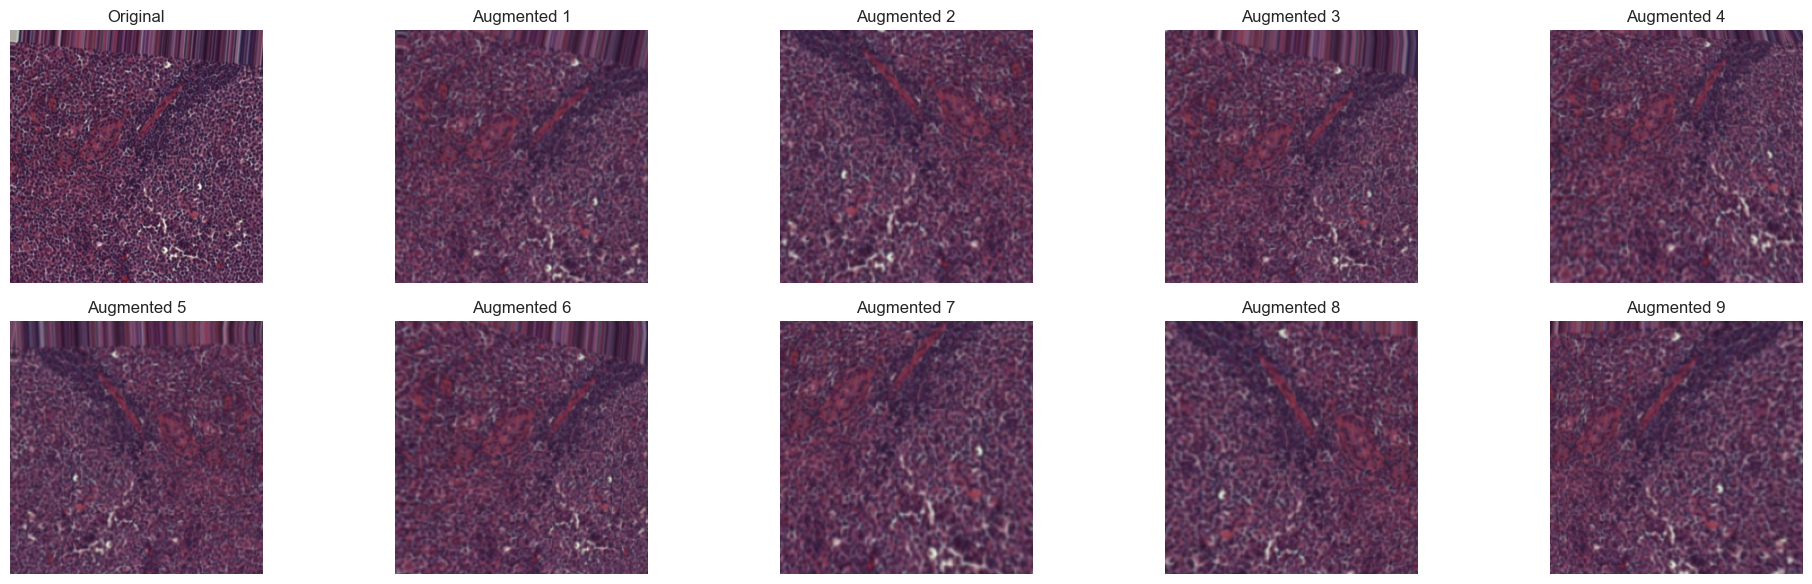

In [44]:
# Pick one random item
item = dls.train_ds[0]
img, label = item

n_aug = 9  # number of augmented images
rows, cols = 2, 5  # grid dimensions
fig, axs = plt.subplots(rows, cols, figsize=(20, 6))

axs = axs.flatten() # Flattening axis for easier indexing

axs[0].imshow(img) # Displaying the original image
axs[0].set_title("Original")
axs[0].axis('off')

# Show augmented images
for i in range(1, n_aug + 1):
    aug_img = dls.train.after_item(img)
    for tfm in dls.train.after_batch.fs:
        aug_img = tfm(aug_img.unsqueeze(0))[0]

    axs[i].imshow(aug_img.permute(1, 2, 0).cpu())
    axs[i].set_title(f"Augmented {i}")
    axs[i].axis('off')

plt.tight_layout()
plt.savefig('plot2.png', bbox_inches='tight', dpi=300)
plt.show()

## Conventional Training

#### ResNet34

Finding optimal learning rate.....


Suggested learning rate: 4.79e-04


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.917345,1.065845,0.592083,0.628146,0.591177,0.538515,11:49
1,0.663959,2.679969,0.361083,0.475768,0.360744,0.290438,11:42
2,0.533177,0.661319,0.728917,0.777167,0.729667,0.716846,11:38
3,0.434694,0.713064,0.749333,0.823208,0.747882,0.745720,12:02
4,0.340005,0.457107,0.814750,0.843648,0.816925,0.804588,11:43
5,0.297992,1.816675,0.476833,0.635345,0.476816,0.428096,11:46
6,0.221004,0.348605,0.880917,0.899126,0.881552,0.875261,11:42
7,0.197788,0.212843,0.918250,0.925928,0.918882,0.917841,11:50
8,0.159101,0.191454,0.926333,0.931442,0.927199,0.925649,11:43
9,0.157752,0.170201,0.934583,0.938483,0.935246,0.934369,11:44


Better model found at epoch 0 with accuracy value: 0.5920833349227905.
Better model found at epoch 2 with accuracy value: 0.7289166450500488.
Better model found at epoch 3 with accuracy value: 0.7493333220481873.
Better model found at epoch 4 with accuracy value: 0.8147500157356262.
Better model found at epoch 6 with accuracy value: 0.8809166550636292.
Better model found at epoch 7 with accuracy value: 0.9182500243186951.
Better model found at epoch 8 with accuracy value: 0.9263333082199097.
Better model found at epoch 9 with accuracy value: 0.934583306312561.


Better model found at epoch 0 with accuracy value: 0.9384833114260913.
Validation Results:
Loss: 0.1702
Accuracy: 0.9346
Precision: 0.9385
Recall: 0.9352
F1 Score: 0.9344


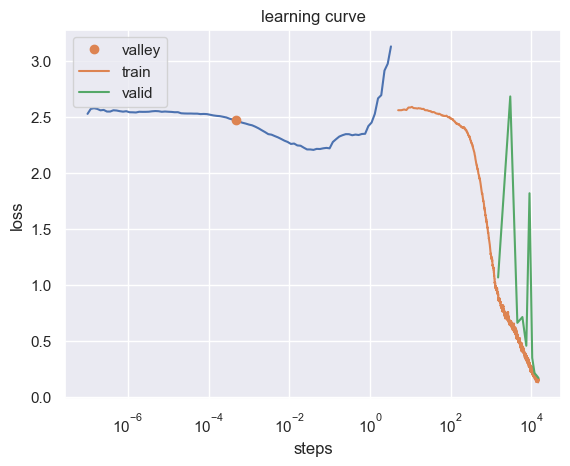

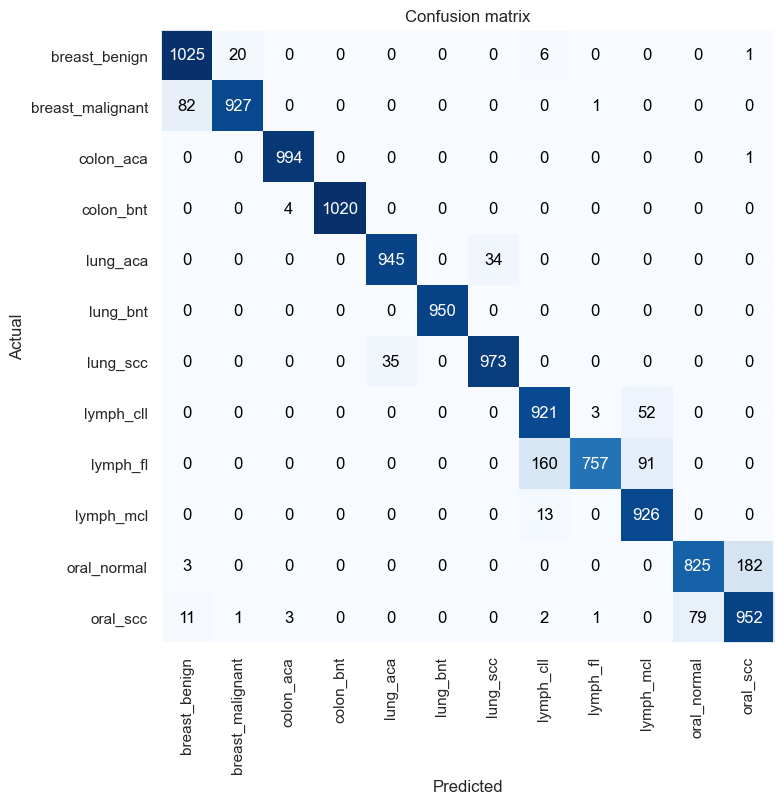

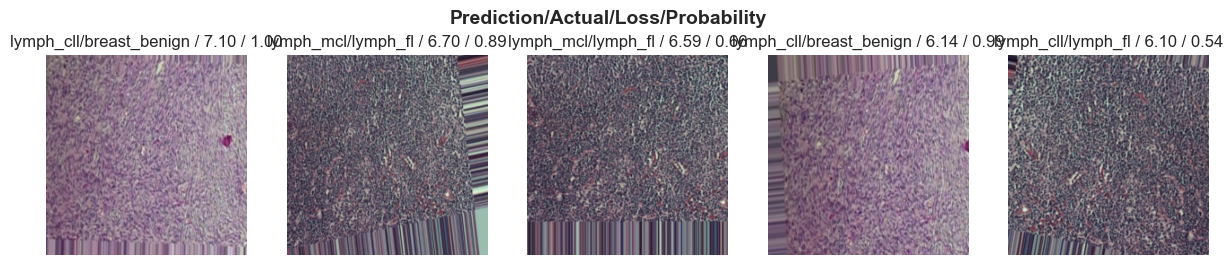

In [48]:
seed = 42
set_seed(seed, reproducible=True)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

def custom_resnet34(num_classes):
    model = models.resnet34(weights=None)      # no pre-training

    # not freezing any layers as trying with a model not pre-trained
    for param in model.parameters():
        param.requires_grad = True

    # Replacing the classifier head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),                   # Randomly setting 50% neurons to 0 to avoid overfitting
        nn.Linear(num_features, 512),      # Fully connected dense layer to reduce dimensionality
        nn.BatchNorm1d(512),               # Stabilizies by normalizing activations from each batch during training
        nn.ReLU(),                         # Adding non-linearity
        nn.Dropout(0.3),                   # Randomly setting 30% neurons to 0
        nn.Linear(512, 256),               # Dense layer
        nn.BatchNorm1d(256),               # normalize new activations
        nn.ReLU(),                         
        nn.Linear(256, num_classes) 
    )
    return model

# Initializing the model for the dataset
num_classes = df['Class'].nunique()
model = custom_resnet34(num_classes)

# Defining the metrics for model
precision = Precision(average='macro')
recall = Recall(average='macro')
f1 = F1Score(average='macro')

learn = Learner(
    dls,
    model,
    loss_func=CrossEntropyLossFlat(),   # Common for multi-class classification problems
    metrics=[accuracy, precision, recall, f1],
    cbs=[
        SaveModelCallback(monitor='accuracy', fname='best_resnet34_cancer'),
        EarlyStoppingCallback(monitor='valid_loss', patience=4),
        TensorBoardCallback(log_dir='runs/cancer_resnet34', trace_model=False)
    ]
).to_fp16() # Mixed precision for faster training

# Finding the optimal learning rate
print(f"Finding optimal learning rate.....")
suggested_lr = learn.lr_find().valley
print(f"Suggested learning rate: {suggested_lr:.2e}")

# Using a smaller learning rate as the model is being trained from scratch
safe_lr = suggested_lr / 5

# Training the model
learn.fit_one_cycle(10, lr_max=safe_lr)

# Track losses and metrics
learn.recorder.plot_loss()

# Validation metrics for the model
val_loss, val_accuracy, val_precision, val_recall, val_f1 = learn.validate()
print("Validation Results:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1 Score: {val_f1:.4f}")

# Creating a Confusion Matrix for better understanding of model accuracy
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8,8))
interp.plot_top_losses(5, nrows=1)

# Saving the model
learn.export('models/resnet34_cancer.pkl')

#### EffiecientNet-B2

In [54]:
# Trying the EffiecientNet-B2 architecture - modern and widely used

def custom_efficientnet_b2(num_classes):
    # loading convnext_tiny model without pretraining
    model = models.efficientnet_b2(weights=None)

    # not freezing any layers as it's being trained from scratch
    for param in model.parameters():
        param.requires_grad = True

    # Replacing the classifier head
    num_features = model.classifier[1].in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),                   # Randomly setting 50% neurons to 0 to avoid overfitting
        nn.Linear(num_features, 512),      # Fully connected dense layer to reduce dimensionality
        nn.BatchNorm1d(512),               # Stabilizies by normalizing activations from each batch during training
        nn.ReLU(),                         # Adding non-linearity
        nn.Dropout(0.3),                   # Randomly setting 30% neurons to 0
        nn.Linear(512, 256),               # Dense layer
        nn.BatchNorm1d(256),               # normalize new activations
        nn.ReLU(),                         
        nn.Linear(256, num_classes) 
    )
    return model

Finding optimal learning rate...


Suggested learning rate: 5.75e-04


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.178999,0.940425,0.594167,0.598637,0.590172,0.565956,13:06
1,0.821327,0.643738,0.698083,0.726463,0.696866,0.679652,13:12
2,0.597373,0.645212,0.733167,0.746302,0.731858,0.729858,13:05
3,0.506336,0.616876,0.741333,0.786596,0.742654,0.722749,13:13
4,0.413150,0.512771,0.772167,0.832589,0.773258,0.754168,13:14
5,0.338943,0.286056,0.886917,0.890470,0.887631,0.886606,13:17
6,0.302359,0.310152,0.866917,0.886968,0.867359,0.864897,13:15
7,0.260057,0.292264,0.884417,0.894807,0.885092,0.880194,13:06
8,0.229866,0.261005,0.901083,0.905654,0.901468,0.900297,13:06
9,0.231186,0.242220,0.906500,0.911128,0.906841,0.906479,13:15


Better model found at epoch 0 with accuracy value: 0.5941666960716248.
Better model found at epoch 1 with accuracy value: 0.6980833411216736.
Better model found at epoch 2 with accuracy value: 0.7331666946411133.
Better model found at epoch 3 with accuracy value: 0.7413333058357239.
Better model found at epoch 4 with accuracy value: 0.7721666693687439.
Better model found at epoch 5 with accuracy value: 0.8869166374206543.
Better model found at epoch 8 with accuracy value: 0.9010833501815796.
Better model found at epoch 9 with accuracy value: 0.906499981880188.


Better model found at epoch 0 with accuracy value: 0.9111283125370995.
Validation Results:
Loss: 0.2422
Accuracy: 0.9065
Precision: 0.9111
Recall: 0.9068
F1 Score: 0.9065


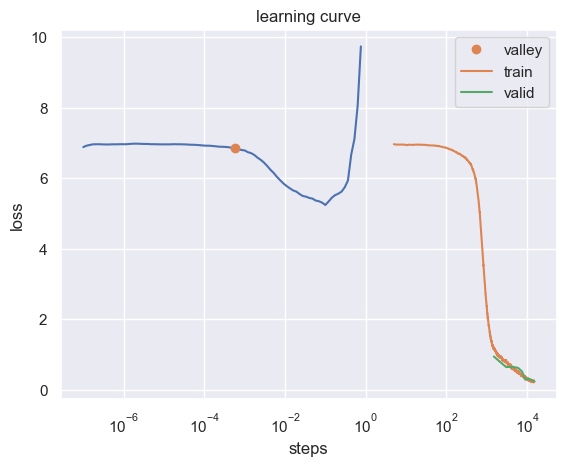

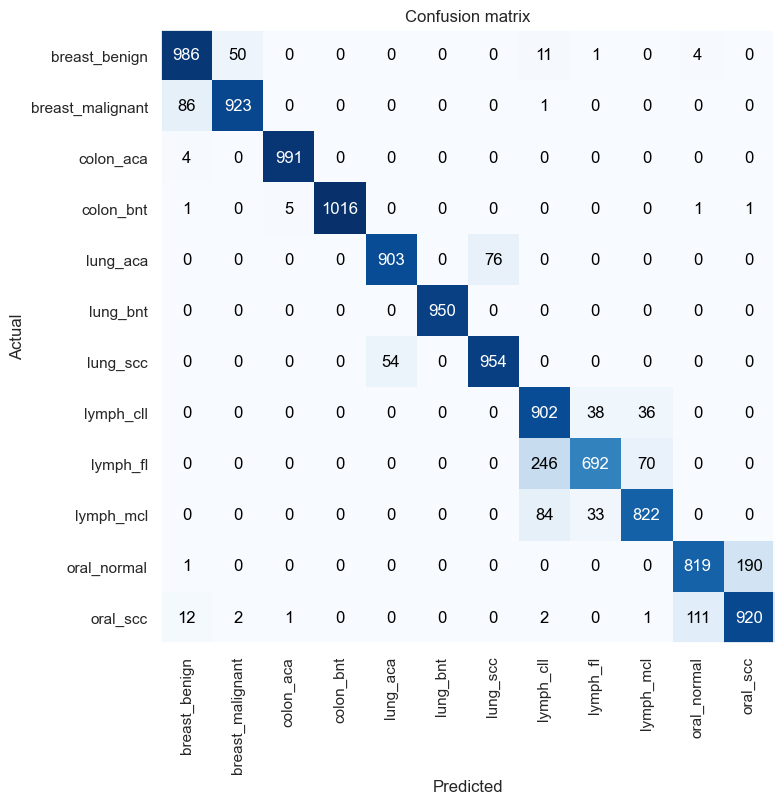

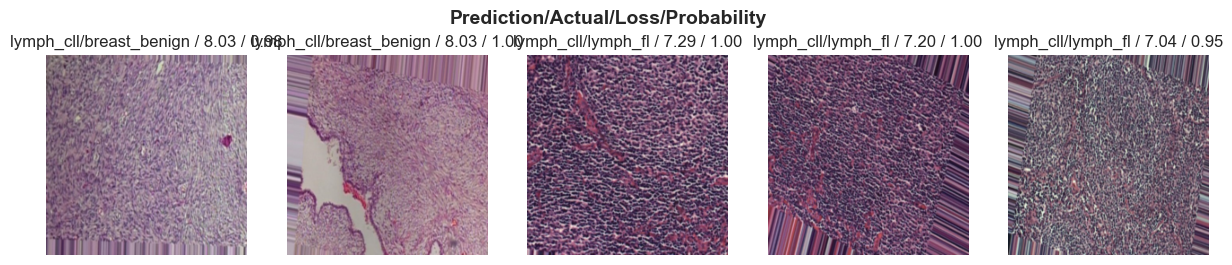

In [56]:
num_classes = df['Class'].nunique()           # Getting the number of unique classes in the dataframe
model_2 = custom_efficientnet_b2(num_classes)     # model for training

# Defining the metrics for model
precision = Precision(average='macro')
recall = Recall(average='macro')
f1 = F1Score(average='macro')

learn_2 = Learner(
    dls,
    model_2,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, precision, recall, f1],      # Using the metrics defined earlier for ResNet34
    cbs=[
        SaveModelCallback(monitor='accuracy', fname='best_efficientnet_b2'),
        EarlyStoppingCallback(monitor='valid_loss', patience=4),
        TensorBoardCallback(log_dir='runs/cancer_efficientnet_b2', trace_model=False)
    ]
).to_fp16()

# Finding the optimal learning rate
print(f"Finding optimal learning rate...")
suggested_lr_2 = learn_2.lr_find().valley
print(f"Suggested learning rate: {suggested_lr_2:.2e}")

# Using a smaller learning rate as the model is being trained from scratch
safe_lr_2 = suggested_lr_2 / 5

# Training the model for 10 epochs
learn_2.fit_one_cycle(10, lr_max=safe_lr_2)

# Tracking losses and metrics
learn_2.recorder.plot_loss()

# Validation metrics for the model
val_loss, val_accuracy, val_precision, val_recall, val_f1 = learn_2.validate()
print("Validation Results:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1 Score: {val_f1:.4f}")

# Creating a Confusion Matrix for better understanding of model accuracy
interp_2 = ClassificationInterpretation.from_learner(learn_2)
interp_2.plot_confusion_matrix(figsize=(8,8))
interp_2.plot_top_losses(5, nrows=1)

# Saving the model
learn_2.export('models/efficientnet_b2.pkl')

#### ViT_B_16

In [58]:
# Trying the Vision Transformer ViT_B_16 architecture 

def custom_vit_b16(num_classes):
    # loading vision transformer model without pretraining
    model = models.vit_b_16(weights=None)

    # not freezing any layers as it's being trained from scratch
    for param in model.parameters():
        param.requires_grad = True

    # Replacing the classifier head
    num_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(0.5),                   # Randomly setting 50% neurons to 0 to avoid overfitting
        nn.Linear(num_features, 512),      # Fully connected dense layer to reduce dimensionality
        nn.BatchNorm1d(512),               # Stabilizies by normalizing activations from each batch during training
        nn.ReLU(),                         # Adding non-linearity
        nn.Dropout(0.3),                   # Randomly setting 30% neurons to 0
        nn.Linear(512, 256),               # Dense layer
        nn.BatchNorm1d(256),               # normalize new activations
        nn.ReLU(),                         
        nn.Linear(256, num_classes) 
    )
    return model

Finding optimal learning rate...


Suggested learning rate: 1.10e-04


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.277741,1.098019,0.631167,0.680946,0.629783,0.609329,17:15
1,0.669713,0.638277,0.750250,0.783609,0.746893,0.737408,17:16
2,0.498545,0.407375,0.832667,0.845943,0.831147,0.827584,17:16
3,0.397749,0.338874,0.865833,0.878773,0.867873,0.864375,17:23
4,0.328273,0.302960,0.878417,0.890641,0.878006,0.876824,17:31
5,0.268610,0.202581,0.922167,0.924703,0.922326,0.921842,17:42
6,0.229606,0.187415,0.923333,0.931244,0.923630,0.922571,17:14
7,0.169589,0.136115,0.947000,0.947483,0.947169,0.947199,17:25
8,0.142025,0.110686,0.957917,0.959061,0.958230,0.958172,17:25
9,0.144673,0.105424,0.961000,0.961444,0.961203,0.961262,17:14


Better model found at epoch 0 with accuracy value: 0.6311666369438171.
Better model found at epoch 1 with accuracy value: 0.750249981880188.
Better model found at epoch 2 with accuracy value: 0.8326666951179504.
Better model found at epoch 3 with accuracy value: 0.8658333420753479.
Better model found at epoch 4 with accuracy value: 0.8784166574478149.
Better model found at epoch 5 with accuracy value: 0.922166645526886.
Better model found at epoch 6 with accuracy value: 0.9233333468437195.
Better model found at epoch 7 with accuracy value: 0.9470000267028809.
Better model found at epoch 8 with accuracy value: 0.9579166769981384.
Better model found at epoch 9 with accuracy value: 0.9610000252723694.


Better model found at epoch 0 with accuracy value: 0.9614443745973905.
Validation Results:
Loss: 0.1054
Accuracy: 0.9610
Precision: 0.9614
Recall: 0.9612
F1 Score: 0.9613


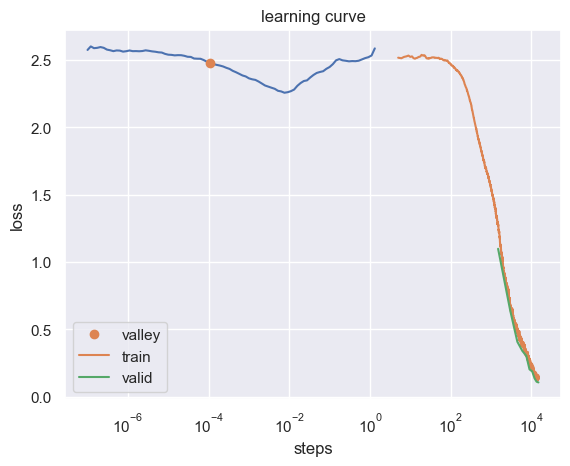

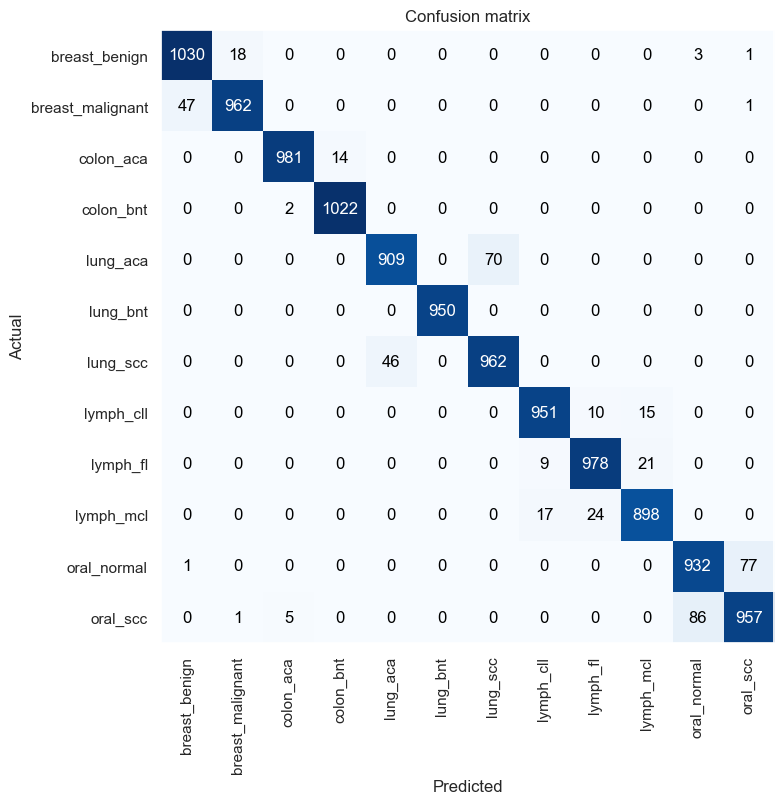

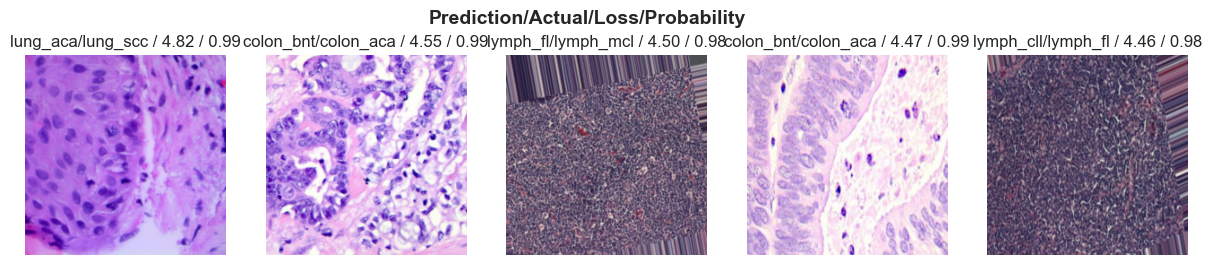

In [60]:
num_classes = df['Class'].nunique()           # Getting the number of unique classes in the dataframe
model_3 = custom_vit_b16(num_classes)     # model for training

# Defining the metrics for model
precision = Precision(average='macro')
recall = Recall(average='macro')
f1 = F1Score(average='macro')

learn_3 = Learner(
    dls,
    model_3,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, precision, recall, f1],      # Using the metrics defined earlier for ResNet34
    cbs=[
        SaveModelCallback(monitor='accuracy', fname='best_vit_b16'),
        EarlyStoppingCallback(monitor='valid_loss', patience=4),
        TensorBoardCallback(log_dir='runs/cancer_vit_b16', trace_model=False)
    ]
).to_fp16()

# Finding the optimal learning rate
print(f"Finding optimal learning rate...")
suggested_lr_3 = learn_3.lr_find().valley
print(f"Suggested learning rate: {suggested_lr_3:.2e}")

# Using a smaller learning rate as the model is being trained from scratch
safe_lr_3 = suggested_lr_3 / 5

# Training the model for 10 epochs
learn_3.fit_one_cycle(10, lr_max=safe_lr_3)

# Tracking losses and metrics
learn_3.recorder.plot_loss()

# Validation metrics for the model
val_loss, val_accuracy, val_precision, val_recall, val_f1 = learn_3.validate()
print("Validation Results:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1 Score: {val_f1:.4f}")

# Creating a Confusion Matrix for better understanding of model accuracy
interp_3 = ClassificationInterpretation.from_learner(learn_3)
interp_3.plot_confusion_matrix(figsize=(8,8))
interp_3.plot_top_losses(5, nrows=1)

# Saving the model
learn_3.export('models/vit_b16.pkl')

#### DeiT_Small_Patch16_224

In [64]:
def custom_deit_small(num_classes):
    # loading deit_small model without pretraining
    model = timm.create_model('deit_small_patch16_224', pretrained=False)

    # not freezing any layers as it's being trained from scratch
    for param in model.parameters():
        param.requires_grad = True

    # Replacing the classifier head
    num_features = model.head.in_features # Getting the number of features from the final layer
    model.head = nn.Sequential(
        nn.Dropout(0.5),                   # Randomly setting 50% neurons to 0 to avoid overfitting
        nn.Linear(num_features, 512),      # Fully connected dense layer to reduce dimensionality
        nn.BatchNorm1d(512),               # Stabilizies by normalizing activations from each batch during training
        nn.ReLU(),                         # Adding non-linearity
        nn.Dropout(0.3),                   # Randomly setting 30% neurons to 0
        nn.Linear(512, 256),               # Dense layer
        nn.BatchNorm1d(256),               # normalize new activations
        nn.ReLU(),                         
        nn.Linear(256, num_classes) 
    )
    return model

Finding optimal learning rate...


Suggested learning rate: 1.32e-04


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.447230,1.254282,0.548750,0.579284,0.548197,0.513633,11:58
1,0.734335,0.694521,0.728333,0.757441,0.727458,0.719860,11:50
2,0.506382,0.475743,0.791750,0.824434,0.791231,0.781316,11:48
3,0.439936,0.388492,0.842333,0.850235,0.842178,0.839494,11:39
4,0.364440,0.270568,0.889583,0.891736,0.890541,0.889776,11:43
5,0.301670,0.243464,0.900083,0.905460,0.901221,0.899943,11:51
6,0.238105,0.193323,0.923667,0.926662,0.924270,0.923948,11:50
7,0.210995,0.179052,0.927000,0.933907,0.928131,0.926979,11:49
8,0.175023,0.142937,0.942917,0.944106,0.943488,0.943316,11:51
9,0.170611,0.134871,0.948083,0.948470,0.948422,0.948400,11:51


Better model found at epoch 0 with accuracy value: 0.5487499833106995.
Better model found at epoch 1 with accuracy value: 0.7283333539962769.
Better model found at epoch 2 with accuracy value: 0.7917500138282776.
Better model found at epoch 3 with accuracy value: 0.8423333168029785.
Better model found at epoch 4 with accuracy value: 0.8895833492279053.
Better model found at epoch 5 with accuracy value: 0.9000833630561829.
Better model found at epoch 6 with accuracy value: 0.9236666560173035.
Better model found at epoch 7 with accuracy value: 0.9269999861717224.
Better model found at epoch 8 with accuracy value: 0.9429166913032532.
Better model found at epoch 9 with accuracy value: 0.9480833411216736.


Better model found at epoch 0 with accuracy value: 0.9484701646869582.
Validation Results:
Loss: 0.1349
Accuracy: 0.9481
Precision: 0.9485
Recall: 0.9484
F1 Score: 0.9484


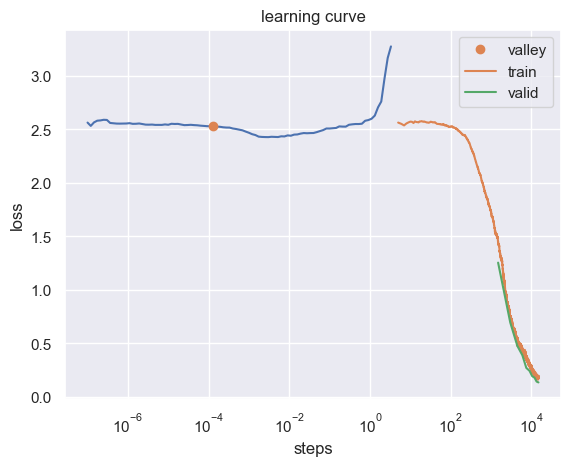

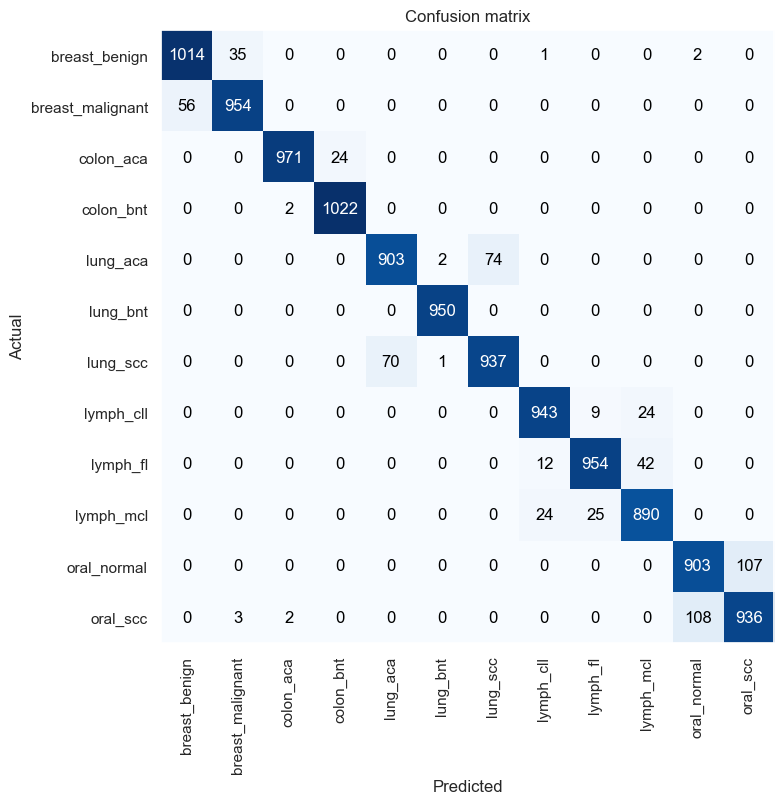

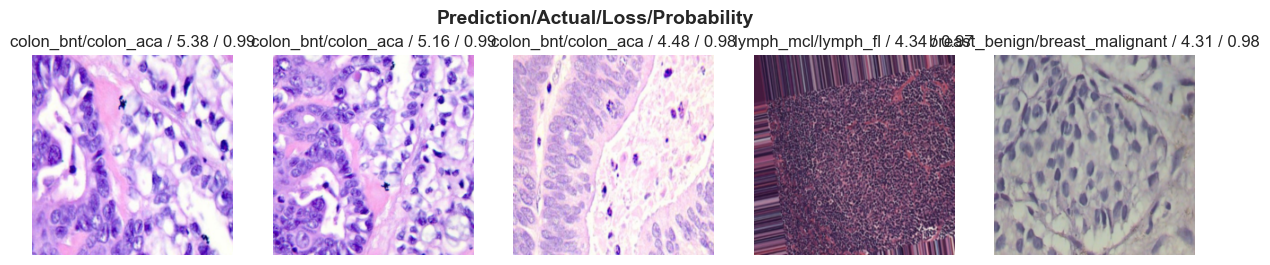

In [66]:
num_classes = df['Class'].nunique()           # Getting the number of unique classes in the dataframe
model_4 = custom_deit_small(num_classes)     # model for training

# Defining the metrics for model
precision = Precision(average='macro')
recall = Recall(average='macro')
f1 = F1Score(average='macro')

learn_4 = Learner(
    dls,
    model_4,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, precision, recall, f1],      # Using the metrics defined earlier for ResNet34
    cbs=[
        SaveModelCallback(monitor='accuracy', fname='best_deit_small_patch16_224'),
        EarlyStoppingCallback(monitor='valid_loss', patience=4),
        TensorBoardCallback(log_dir='runs/cancer_deit_small', trace_model=False)
    ]
).to_fp16()

# Finding the optimal learning rate
print(f"Finding optimal learning rate...")
suggested_lr_4 = learn_4.lr_find().valley
print(f"Suggested learning rate: {suggested_lr_4:.2e}")

# Using a smaller learning rate as the model is being trained from scratch
safe_lr_4 = suggested_lr_4 / 5

# Training the model for 10 epochs
learn_4.fit_one_cycle(10, lr_max=safe_lr_4)

# Tracking losses and metrics
learn_4.recorder.plot_loss()

# Validation metrics for the model
val_loss, val_accuracy, val_precision, val_recall, val_f1 = learn_4.validate()
print("Validation Results:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1 Score: {val_f1:.4f}")

# Creating a Confusion Matrix for better understanding of model accuracy
interp_4 = ClassificationInterpretation.from_learner(learn_4)
interp_4.plot_confusion_matrix(figsize=(8,8))
interp_4.plot_top_losses(5, nrows=1)

# Saving the model
learn_4.export('models/deit_small.pkl')

In [ ]:
# Adding columns to the dataframe for segregation by main cancer type 

In [47]:
# New try
# Slightly modifying the dataframe structure for ease of use
import os

# Derive clear Cancer_Type from path (handles 'Lung and Colon' issue)
def extract_cancer_type(path):
    parts = os.path.normpath(path).split(os.sep)
    sub_folder = parts[-2].lower()  # e.g. 'lung_aca' or 'colon_benign'
    if 'lung' in sub_folder:
        return 'Lung'
    elif 'colon' in sub_folder:
        return 'Colon'
    elif 'breast' in sub_folder:
        return 'Breast'
    elif 'oral' in sub_folder:
        return 'Oral'
    elif 'lymph' in sub_folder:
        return 'Lymphoma'
    else:
        return 'Unknown'

df['Cancer_Type'] = df['Path'].apply(extract_cancer_type)
df['Sub_Class'] = df['Class']

print(df[['Cancer_Type', 'Sub_Class']].head())
print(f"Unique cancer types found: {df['Cancer_Type'].unique()}")

     Cancer_Type      Sub_Class
0         Breast  breast_benign
3336      Breast  breast_benign
3335      Breast  breast_benign
3334      Breast  breast_benign
3333      Breast  breast_benign
Unique cancer types found: ['Breast' 'Colon' 'Lung' 'Lymphoma' 'Oral']


In [49]:
def set_seed_everywhere(seed=42):  # for reproducibilty setting the seed as 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed, reproducible=True)

## Internal Transfer Learning
#### Trying zero-shot training where the model is trained on one subclass of a cancertype from the dataset and then, tested on the remaining subclasses of that particular cancer type in one go.
#### This pre-trained model from zero-shot training is then used to train on only 5% of the images from that cancer type and then tested on the remaining 95% images in one go. This is called as few-shots training where the model is trained on very less number of samples.
#### This entire process collectively is termed as internal transfer learning.

#### Function for zero-shot transfer learning training

In [53]:
def internal_transfer_learning(df, target_type, model_func, num_epochs=5, seed=42):

    set_seed_everywhere(seed)

    df_type = df[df['Cancer_Type'] == target_type] # Filtering the data for chosen cancer type
    sub_classes = df_type['Sub_Class'].unique()

    print(f"\nCancer Type: {target_type}")
    print(f"Available sub-classes: {list(sub_classes)}")

    # Choosing one subclass for training, and remaining for testing
    train_subclass = sub_classes[0]        # choosing the first subclass for training
    test_subclasses = [sc for sc in sub_classes if sc != train_subclass]

    print(f"Training on: {train_subclass}")
    print(f"Zero-shot testing on: {test_subclasses}")

    df_train = df_type[df_type['Sub_Class'] == train_subclass]         # Creating separate training and testing dataframes
    df_test = df_type[df_type['Sub_Class'].isin(test_subclasses)]

    print(f"Train samples: {len(df_train)}, Test samples: {len(df_test)}")

    # Datablock for training
    train_dblock = DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_x=ColReader('Path'),
        get_y=ColReader('Sub_Class'),
        item_tfms=Resize(224, method='pad'),
        batch_tfms=aug_transforms(size=224, min_scale=0.75, max_lighting=0.2, max_zoom=1.1)
    )

    # Datablock for testing on multiple classes
    test_dblock = DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_x=ColReader('Path'),
        get_y=ColReader('Sub_Class'),
        item_tfms=Resize(224, method='pad'),
        batch_tfms=aug_transforms(size=224, min_scale=0.75, max_lighting=0.2, max_zoom=1.1)
    )

    # Creating the training and testing dataloaders
    train_dls = train_dblock.dataloaders(df_train, valid_pct=0.0, seed=seed, bs=32)
    
    # Getting the total number of images before and after augmentation
    print("\nAugmentation Analysis:")
    original_size = len(train_dls.train_ds.items)
    images_per_epoch = original_size
    total_augmented = images_per_epoch * num_epochs

    print(f"Original images: {original_size}")
    print(f"Images processed per epoch: {images_per_epoch}")
    print(f"Total augmented views over {num_epochs} epochs: {total_augmented}")
    
    test_dls = test_dblock.dataloaders(df_test, valid_pct=0.0, seed=seed, bs=32)

    # Model and learner setup
    #num_train_classes = len(train_subclass)
    #print(f"Number of test classes: {num__test_classes}")
    num_all_classes = len(sub_classes)
    model = model_func(num_all_classes)
    #model = model_func(num_train_classes)

    learn = Learner(
        train_dls,
        model,
        loss_func=CrossEntropyLossFlat(),
        metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
        cbs=[]
    ).to_fp16()

    # Finding the optimal Learning rate and training the model
    learn.lr_find()
    train_lr = learn.lr_find().valley / 3  # Conservative LR because implementing from scratch training
    print(f"Train set learning rate: {train_lr:.2e}")

    # Training the model
    print("\n Starting training...")
    learn.fit_one_cycle(num_epochs, lr_max=train_lr)

    # Zero-shot evaluation on unseen classes
    learn_test = Learner(
        test_dls,
        learn.model,  # Using the trained model
        loss_func=CrossEntropyLossFlat(),
        metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')]
    ).to_fp16()
    
    results = learn_test.validate()
    print(f"\nZero-shot results on {test_subclasses}:")
    print(f"Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}, Precision: {results[2]:.4f}, Recall: {results[3]:.4f}, F1: {results[4]:.4f}")

    return learn, results, train_subclass, test_subclasses

#### Function for few-shots transfer learning

In [56]:
def few_shots_training(df, target_type, model_func, pretrained_learner, fraction=0.05, num_epochs=5, seed=42):
    set_seed_everywhere(seed)
    df_type = df[df['Cancer_Type'] == target_type] # Filtering the data for chosen cancer type
    sub_classes = df_type['Sub_Class'].unique()
    print(f"\nCancer Type: {target_type}")
    print(f"Available sub-classes: {list(sub_classes)}")

    train_subclass = pretrained_learner.train_subclass if hasattr(pretrained_learner, 'train_subclass') else sub_classes[0] # Identifying the subclasses used in the case of zero-shot
    test_subclasses = [sc for sc in sub_classes if sc != train_subclass]

    print(f"Few-shot training on: {test_subclasses} (5% of data)")
    df_test = df_type[df_type['Sub_Class'].isin(test_subclasses)]
    
    # Splitting the test data into few-shot (5%) and holdout (95%) for testing
    few_shot_df = df_test.sample(frac=fraction, random_state=seed)
    holdout_df = df_test.drop(few_shot_df.index)
    print(f"Few-shot samples: {len(few_shot_df)}, Holdout samples: {len(holdout_df)}")

    dblock = DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_x=ColReader('Path'),
        get_y=ColReader('Sub_Class'),
        item_tfms=Resize(224, method='pad'),
        batch_tfms=aug_transforms(size=224, min_scale=0.75, max_lighting=0.2, max_zoom=1.1)
    )
    dls_fewshot = dblock.dataloaders(few_shot_df, valid_pct=0.0, seed=seed, bs=16)
    dls_holdout = dblock.dataloaders(holdout_df, valid_pct=0.0, seed=seed, bs=16)

    learn_fewshot = Learner(
        dls_fewshot,
        pretrained_learner.model,
        loss_func = CrossEntropyLossFlat(),
        metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    ).to_fp16()

    print("\nStarting few-shot fine-tuning...")
    learn_fewshot.fit_one_cycle(num_epochs, lr_max=1e-4)
    print("\nEvaluating on holdout (unseen 95%)...")
    fewshot_results = learn_fewshot.validate(dl=dls_holdout.train)

    print(f"\nFew-shot Results on unseen 95%:")
    print(f"Loss: {fewshot_results[0]:.4f}, Acc: {fewshot_results[1]:.4f}, "
          f"Precision: {fewshot_results[2]:.4f}, Recall: {fewshot_results[3]:.4f}, F1: {fewshot_results[4]:.4f}")

    return learn_fewshot, fewshot_results, few_shot_df, holdout_df

#### Internal Transfer - EfficientNet-B2

In [104]:
def transfer_efficientnet_b2(num_classes):
    model = models.efficientnet_b2(weights=None)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
            nn.Dropout(0.5),                   # Randomly setting 50% neurons to 0 to avoid overfitting
            nn.Linear(num_features, 512),      # Fully connected dense layer to reduce dimensionality
            nn.BatchNorm1d(512),               # Stabilizies by normalizing activations from each batch during training
            nn.ReLU(),                         # Adding non-linearity
            nn.Dropout(0.3),                   # Randomly setting 30% neurons to 0
            nn.Linear(512, 256),               # Dense layer
            nn.BatchNorm1d(256),               # normalize new activations
            nn.ReLU(),                         
            nn.Linear(256, num_classes)
    )
    return model

#### Zero-shot Lung cancer using efficient_net_b2


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Training on: lung_aca
Zero-shot testing on: ['lung_bnt', 'lung_scc']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 8.37e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.275517,0.204198,0.954000,0.500000,0.477000,0.488229,01:03
1,0.028214,0.014275,1.000000,1.000000,1.000000,1.000000,01:00
2,0.004770,0.003104,1.000000,1.000000,1.000000,1.000000,00:59
3,0.001834,0.001866,1.000000,1.000000,1.000000,1.000000,00:59
4,0.001339,0.001869,1.000000,1.000000,1.000000,1.000000,01:01



Zero-shot results on ['lung_bnt', 'lung_scc']:
Loss: 3.7908, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


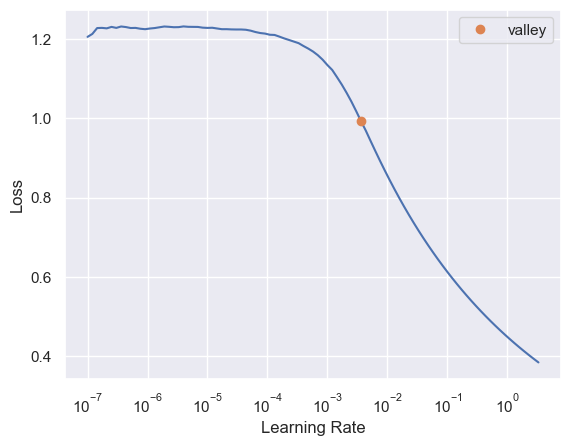

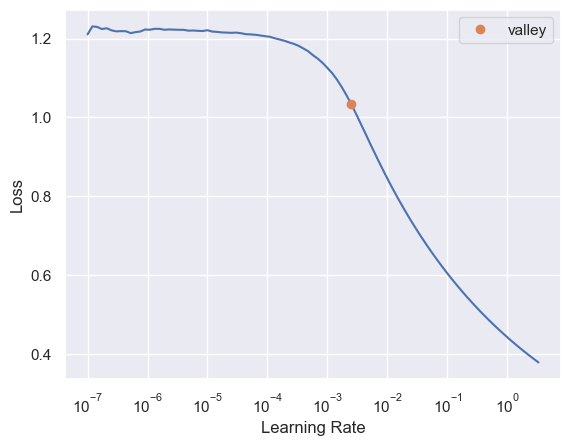

In [82]:
learn, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lung',
    model_func=transfer_efficientnet_b2,
    num_epochs=5
)

#### Few-shots for Lung cancer using efficient_net_b2

In [85]:
learn_few, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lung',
    model_func=transfer_efficientnet_b2,
    pretrained_learner=learn,
    num_epochs=5
)


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Few-shot training on: ['lung_bnt', 'lung_scc'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,3.651319,5.809842,0.510000,0.255000,0.500000,0.337748,00:08
1,2.662244,1.834859,0.510000,0.255000,0.500000,0.337748,00:08
2,1.774123,0.730470,0.920000,0.923232,0.919168,0.919711,00:08
3,1.273896,0.479724,0.940000,0.940988,0.939576,0.939904,00:07
4,0.966291,0.460130,0.920000,0.922120,0.920768,0.919968,00:07



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 1.1469, Acc: 0.8583, Precision: 0.8804, Recall: 0.8596, F1: 0.8565


#### Zero-shot training on Lymphoma


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Training on: lymph_cll
Zero-shot testing on: ['lymph_fl', 'lymph_mcl']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 8.37e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.277834,0.841583,0.717000,0.333333,0.239000,0.278393,01:13
1,0.028147,0.052452,1.000000,1.000000,1.000000,1.000000,01:12
2,0.004663,0.005777,1.000000,1.000000,1.000000,1.000000,01:11
3,0.001778,0.004274,1.000000,1.000000,1.000000,1.000000,01:11
4,0.001388,0.004697,1.000000,1.000000,1.000000,1.000000,01:12



Zero-shot results on ['lymph_fl', 'lymph_mcl']:
Loss: 3.8935, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


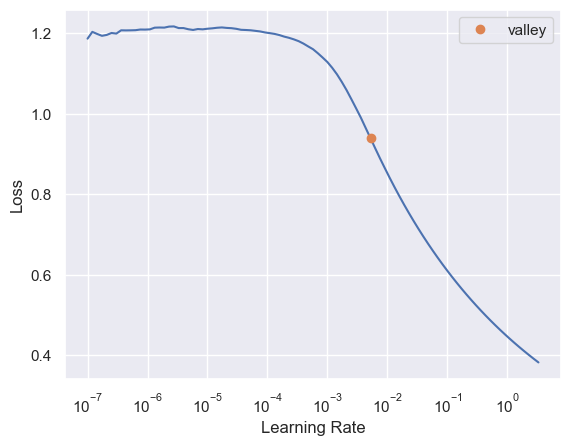

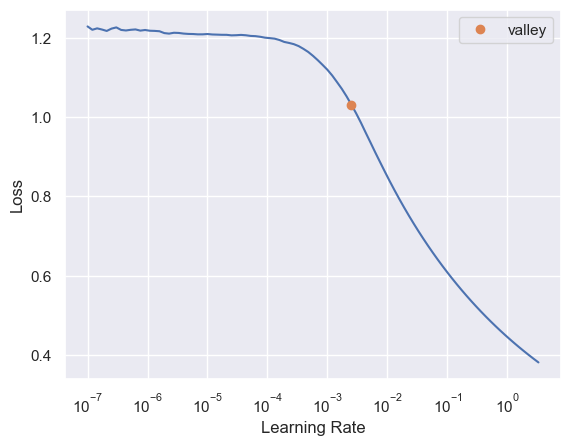

In [96]:
learn_lym, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_efficientnet_b2,
    num_epochs=5
)

#### Few shots testing on Lymphoma

In [99]:
learn_few_lymph, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_efficientnet_b2,
    pretrained_learner=learn_lym,
    num_epochs=5
)


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Few-shot training on: ['lymph_fl', 'lymph_mcl'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,3.792704,11.712477,0.510000,0.255000,0.500000,0.337748,00:12
1,3.569208,37.302010,0.510000,0.255000,0.500000,0.337748,00:12
2,3.143904,63.840599,0.510000,0.255000,0.500000,0.337748,00:12
3,2.732021,81.251450,0.510000,0.255000,0.500000,0.337748,00:12
4,2.466147,76.510551,0.510000,0.255000,0.500000,0.337748,00:12



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 3.5408, Acc: 0.5054, Precision: 0.2527, Recall: 0.5000, F1: 0.3357


#### Zero-shot training on Breast cancer


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Training on: breast_benign
Zero-shot testing on: ['breast_malignant']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 1.75e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.077254,0.137433,0.970000,0.500000,0.485000,0.492386,01:06
1,0.007120,0.107252,0.971000,0.500000,0.485500,0.492643,01:00
2,0.001083,0.000744,1.000000,1.000000,1.000000,1.000000,01:02
3,0.000387,0.000581,1.000000,1.000000,1.000000,1.000000,00:59
4,0.000287,0.000725,1.000000,1.000000,1.000000,1.000000,01:03



Zero-shot results on ['breast_malignant']:
Loss: 0.0004, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


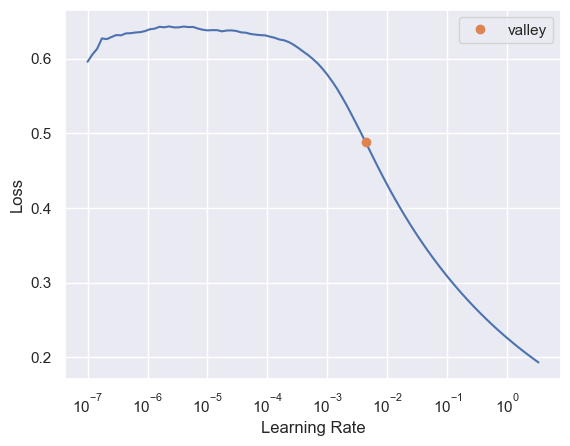

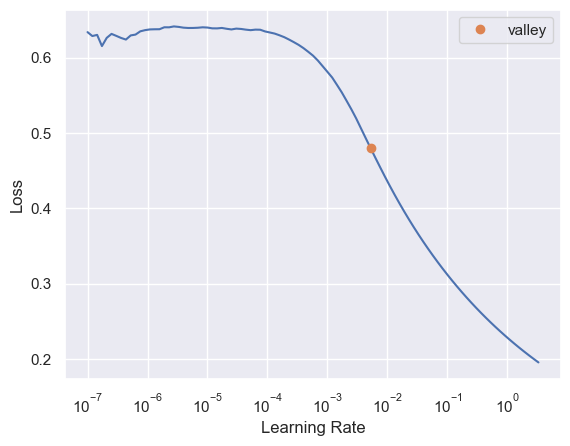

In [93]:
learn_1, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Breast',
    model_func=transfer_efficientnet_b2,
    num_epochs=5
)

#### Few Shots training on Breast cancer

In [74]:
learn_eff, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Breast',
    model_func=transfer_efficientnet_b2,
    pretrained_learner=learn_1,
    num_epochs=5
)


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Few-shot training on: ['breast_malignant'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000636,0.000647,1.000000,1.000000,1.000000,1.000000,00:04
1,0.000538,0.000704,1.000000,1.000000,1.000000,1.000000,00:04
2,0.000465,0.000607,1.000000,1.000000,1.000000,1.000000,00:04
3,0.000412,0.000682,1.000000,1.000000,1.000000,1.000000,00:04
4,0.000375,0.000626,1.000000,1.000000,1.000000,1.000000,00:04



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0005, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot training on Oral cancer


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Training on: oral_normal
Zero-shot testing on: ['oral_scc']
Train samples: 5001, Test samples: 5001

Augmentation Analysis:
Original images: 4001
Images processed per epoch: 4001
Total augmented views over 5 epochs: 20005


Train set learning rate: 1.75e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.078627,0.018217,0.997000,0.500000,0.498500,0.499249,01:57
1,0.007270,0.013009,0.998000,0.500000,0.499000,0.499499,01:57
2,0.001083,0.003221,1.000000,1.000000,1.000000,1.000000,01:53
3,0.000387,0.000714,1.000000,1.000000,1.000000,1.000000,01:55
4,0.000278,0.000620,1.000000,1.000000,1.000000,1.000000,02:00



Zero-shot results on ['oral_scc']:
Loss: 0.0005, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


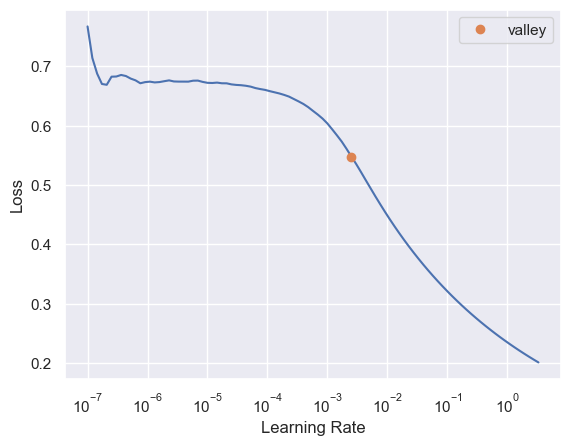

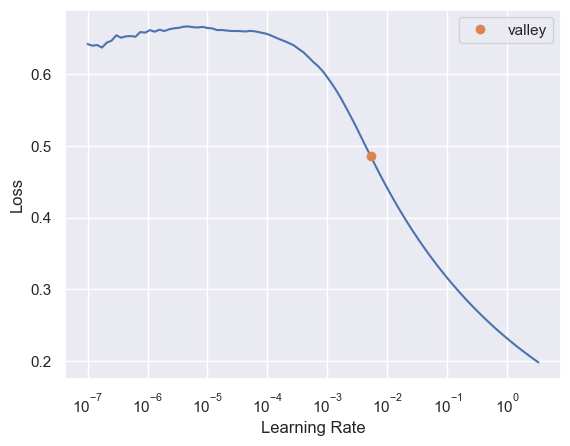

In [107]:
learn_eff_or, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Oral',
    model_func=transfer_efficientnet_b2,
    num_epochs=5
)

#### Few Shots training on Oral cancer

In [110]:
learn_eff_or_few, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Oral',
    model_func=transfer_efficientnet_b2,
    pretrained_learner=learn_eff_or,
    num_epochs=5
)


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Few-shot training on: ['oral_scc'] (5% of data)
Few-shot samples: 250, Holdout samples: 4751

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000293,0.000393,1.000000,1.000000,1.000000,1.000000,00:07
1,0.000263,0.000292,1.000000,1.000000,1.000000,1.000000,00:06
2,0.000254,0.000230,1.000000,1.000000,1.000000,1.000000,00:07
3,0.000229,0.000230,1.000000,1.000000,1.000000,1.000000,00:06
4,0.000210,0.000196,1.000000,1.000000,1.000000,1.000000,00:07



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0003, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot training on Colon cancer


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Training on: colon_aca
Zero-shot testing on: ['colon_bnt']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 1.21e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.099996,0.764879,0.847000,0.500000,0.423500,0.458581,02:22
1,0.009935,0.016401,1.000000,1.000000,1.000000,1.000000,02:15
2,0.001667,0.002840,1.000000,1.000000,1.000000,1.000000,02:16
3,0.000649,0.002111,1.000000,1.000000,1.000000,1.000000,02:16
4,0.000491,0.002588,1.000000,1.000000,1.000000,1.000000,02:16



Zero-shot results on ['colon_bnt']:
Loss: 0.0053, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


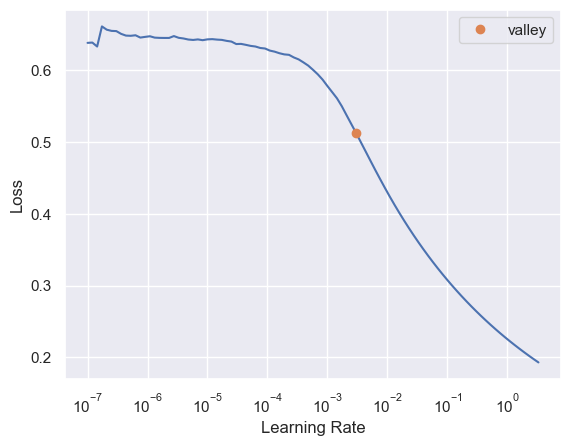

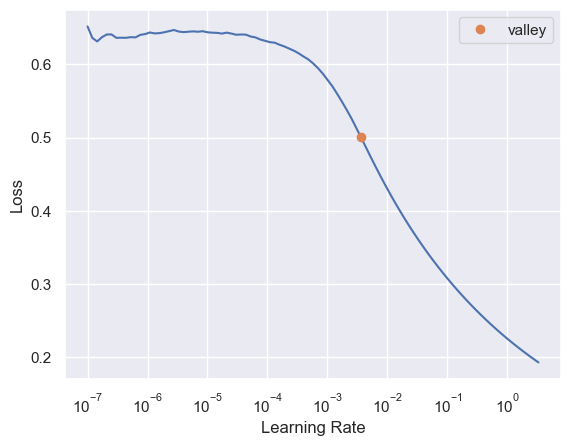

In [113]:
learn_eff_col, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Colon',
    model_func=transfer_efficientnet_b2,
    num_epochs=5
)

#### Few Shots training on Colon cancer

In [116]:
learn_eff_col_few, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Colon',
    model_func=transfer_efficientnet_b2,
    pretrained_learner=learn_eff_col,
    num_epochs=5
)


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Few-shot training on: ['colon_bnt'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000516,0.001230,1.000000,1.000000,1.000000,1.000000,00:09
1,0.000482,0.000557,1.000000,1.000000,1.000000,1.000000,00:08
2,0.000460,0.000452,1.000000,1.000000,1.000000,1.000000,00:08
3,0.000406,0.000447,1.000000,1.000000,1.000000,1.000000,00:08
4,0.000373,0.000421,1.000000,1.000000,1.000000,1.000000,00:08



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0005, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Internal Transfer - ResNet34

In [89]:
def transfer_resnet_34(num_classes):
    model = models.resnet34(weights=None)
    num_features = model.fc.in_features
    model.classifier = nn.Sequential(
            nn.Dropout(0.5),                   # Randomly setting 50% neurons to 0 to avoid overfitting
            nn.Linear(num_features, 512),      # Fully connected dense layer to reduce dimensionality
            nn.BatchNorm1d(512),               # Stabilizies by normalizing activations from each batch during training
            nn.ReLU(),                         # Adding non-linearity
            nn.Dropout(0.3),                   # Randomly setting 30% neurons to 0
            nn.Linear(512, 256),               # Dense layer
            nn.BatchNorm1d(256),               # normalize new activations
            nn.ReLU(),                         
            nn.Linear(256, num_classes)
    )
    return model

#### Zero-shot for Breast cancer using resnet_34


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Training on: breast_benign
Zero-shot testing on: ['breast_malignant']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 4.01e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.503331,0.004311,1.000000,1.000000,1.000000,1.000000,00:52
1,0.039119,0.001374,1.000000,1.000000,1.000000,1.000000,00:54
2,0.003929,0.000755,1.000000,1.000000,1.000000,1.000000,00:57
3,0.000847,0.000544,1.000000,1.000000,1.000000,1.000000,00:56
4,0.000526,0.000502,1.000000,1.000000,1.000000,1.000000,00:57



Zero-shot results on ['breast_malignant']:
Loss: 0.0005, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


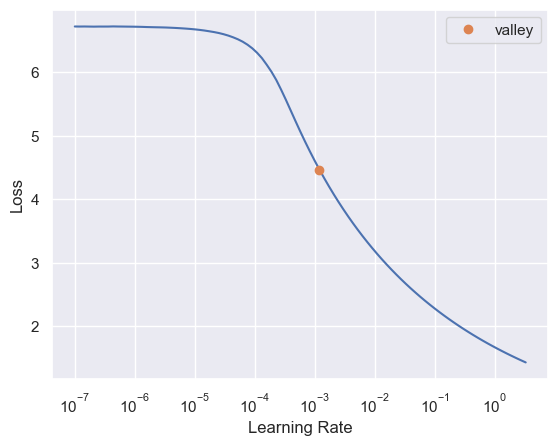

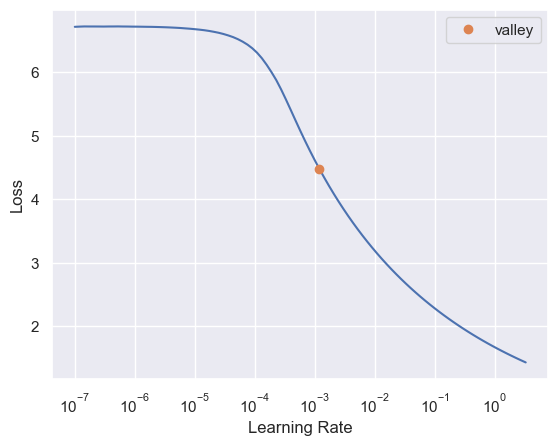

In [105]:
learn_2, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Breast',
    model_func=transfer_resnet_34,
    num_epochs=5
)

#### Few-shots for Breast cancer using ResNet34

In [108]:
learn_res, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Breast',
    model_func=transfer_resnet_34,
    pretrained_learner=learn_2,
    num_epochs=5
)


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Few-shot training on: ['breast_malignant'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000482,0.000358,1.000000,1.000000,1.000000,1.000000,00:04
1,0.000384,0.000203,1.000000,1.000000,1.000000,1.000000,00:04
2,0.000301,0.000162,1.000000,1.000000,1.000000,1.000000,00:04
3,0.000246,0.000139,1.000000,1.000000,1.000000,1.000000,00:04
4,0.000211,0.000137,1.000000,1.000000,1.000000,1.000000,00:04



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0001, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot for Lung cancer using resnet_34


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Training on: lung_aca
Zero-shot testing on: ['lung_bnt', 'lung_scc']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 4.01e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.639054,0.006325,1.000000,1.000000,1.000000,1.000000,00:56
1,0.049415,0.006437,0.998000,0.500000,0.499000,0.499499,00:58
2,0.004814,0.001364,1.000000,1.000000,1.000000,1.000000,00:56
3,0.000939,0.000621,1.000000,1.000000,1.000000,1.000000,00:55
4,0.000571,0.005711,0.998000,0.500000,0.499000,0.499499,00:53



Zero-shot results on ['lung_bnt', 'lung_scc']:
Loss: 6.8520, Accuracy: 0.5050, Precision: 0.1684, Recall: 0.3333, F1: 0.2238


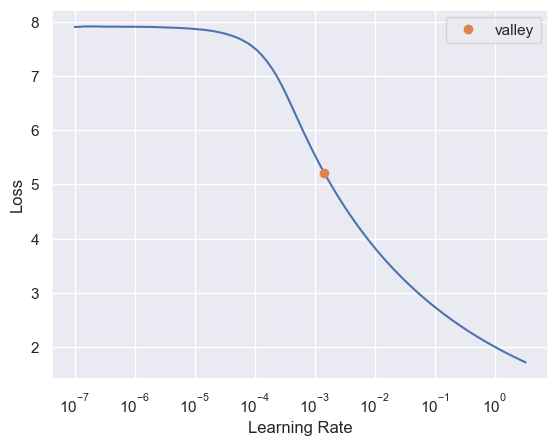

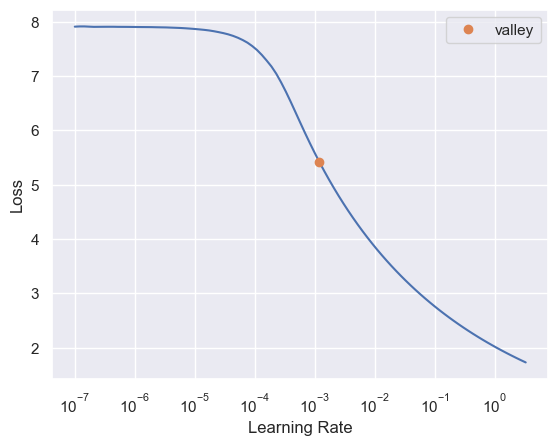

In [111]:
learn_3, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lung',
    model_func=transfer_resnet_34,
    num_epochs=5
)

#### Few-shots for Lung cancer using resnet_34

In [113]:
learn_few_1, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lung',
    model_func=transfer_resnet_34,
    pretrained_learner=learn_3,
    num_epochs=5
)


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Few-shot training on: ['lung_bnt', 'lung_scc'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,5.595439,3.125602,0.510000,0.255000,0.500000,0.337748,00:06
1,2.502021,0.078319,0.980000,0.979992,0.979992,0.979992,00:06
2,1.286367,0.119882,0.940000,0.945455,0.941176,0.939904,00:06
3,0.724901,0.044625,0.980000,0.979992,0.979992,0.979992,00:06
4,0.427462,0.035751,0.980000,0.979992,0.979992,0.979992,00:06



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0507, Acc: 0.9833, Precision: 0.9836, Recall: 0.9835, F1: 0.9833


#### Zero-shot for Oral cancer using resnet_34


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Training on: oral_normal
Zero-shot testing on: ['oral_scc']
Train samples: 5001, Test samples: 5001

Augmentation Analysis:
Original images: 4001
Images processed per epoch: 4001
Total augmented views over 5 epochs: 20005


Train set learning rate: 4.01e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.511378,0.004444,1.000000,1.000000,1.000000,1.000000,00:57
1,0.039656,0.001335,1.000000,1.000000,1.000000,1.000000,00:54
2,0.003930,0.000690,1.000000,1.000000,1.000000,1.000000,00:51
3,0.000812,0.000487,1.000000,1.000000,1.000000,1.000000,00:53
4,0.000497,0.000467,1.000000,1.000000,1.000000,1.000000,00:51



Zero-shot results on ['oral_scc']:
Loss: 0.0005, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


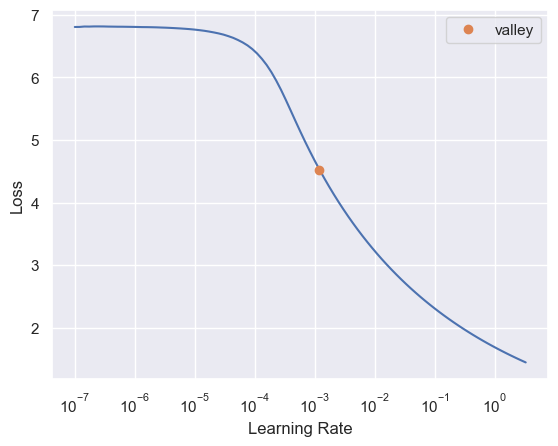

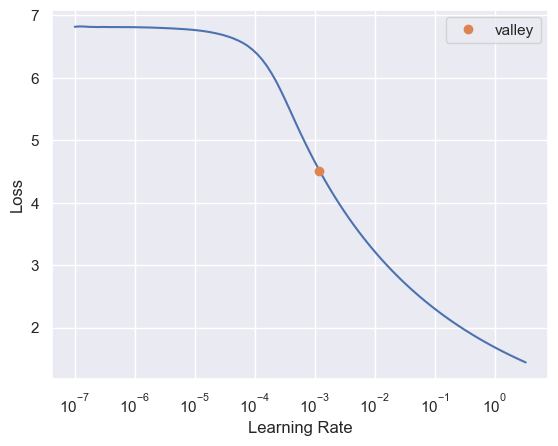

In [117]:
learn_4, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Oral',
    model_func=transfer_resnet_34,
    num_epochs=5
)

#### Few-shots for Oral cancer using resnet_34

In [119]:
learn_few_res34, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Oral',
    model_func=transfer_resnet_34,
    pretrained_learner=learn_4,
    num_epochs=5
)


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Few-shot training on: ['oral_scc'] (5% of data)
Few-shot samples: 250, Holdout samples: 4751

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000465,0.000321,1.000000,1.000000,1.000000,1.000000,00:03
1,0.000376,0.000216,1.000000,1.000000,1.000000,1.000000,00:03
2,0.000295,0.000144,1.000000,1.000000,1.000000,1.000000,00:03
3,0.000237,0.000117,1.000000,1.000000,1.000000,1.000000,00:03
4,0.000201,0.000114,1.000000,1.000000,1.000000,1.000000,00:03



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0001, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot for Lymphoma using ResNet34


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Training on: lymph_cll
Zero-shot testing on: ['lymph_fl', 'lymph_mcl']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 4.01e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.683996,0.004573,1.000000,1.000000,1.000000,1.000000,00:57
1,0.052816,0.001404,1.000000,1.000000,1.000000,1.000000,00:57
2,0.005118,0.000669,1.000000,1.000000,1.000000,1.000000,00:57
3,0.000989,0.000503,1.000000,1.000000,1.000000,1.000000,00:56
4,0.000586,0.000402,1.000000,1.000000,1.000000,1.000000,00:58



Zero-shot results on ['lymph_fl', 'lymph_mcl']:
Loss: 7.0030, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


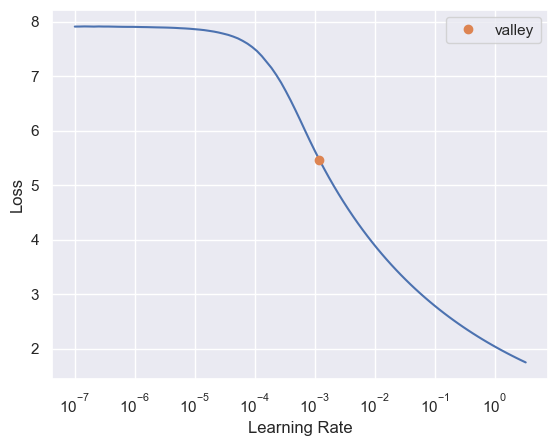

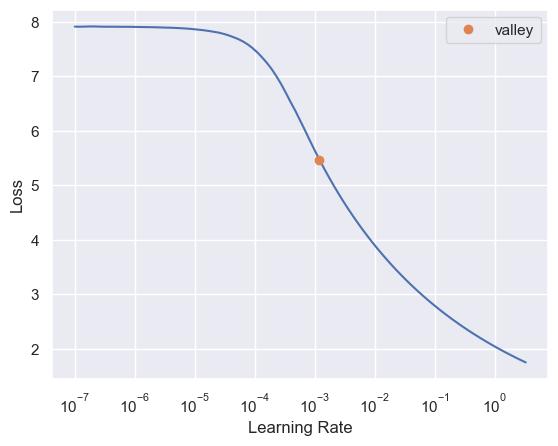

In [125]:
learn_lymph, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_resnet_34,
    num_epochs=5
)

#### Few shots testing on Lymphoma

In [127]:
learn_few_reslymph, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_resnet_34,
    pretrained_learner=learn_lymph,
    num_epochs=5
)


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Few-shot training on: ['lymph_fl', 'lymph_mcl'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,6.190258,11.839774,0.510000,0.255000,0.500000,0.337748,00:07
1,3.724831,1.744324,0.720000,0.733162,0.717487,0.714402,00:07
2,2.299695,4.164574,0.690000,0.810976,0.683673,0.652115,00:07
3,1.608267,3.011777,0.540000,0.597070,0.531813,0.441476,00:07
4,1.218480,2.550362,0.610000,0.652098,0.604442,0.574189,00:06



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.6540, Acc: 0.6850, Precision: 0.6907, Recall: 0.6859, F1: 0.6833


#### Zero-shot for Colon cancer using ResNet34


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Training on: colon_aca
Zero-shot testing on: ['colon_bnt']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 4.01e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.470974,0.004460,1.000000,1.000000,1.000000,1.000000,00:57
1,0.036785,0.001530,1.000000,1.000000,1.000000,1.000000,00:54
2,0.003782,0.000802,1.000000,1.000000,1.000000,1.000000,00:49
3,0.000863,0.000567,1.000000,1.000000,1.000000,1.000000,00:50
4,0.000556,0.000522,1.000000,1.000000,1.000000,1.000000,00:51



Zero-shot results on ['colon_bnt']:
Loss: 0.0005, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


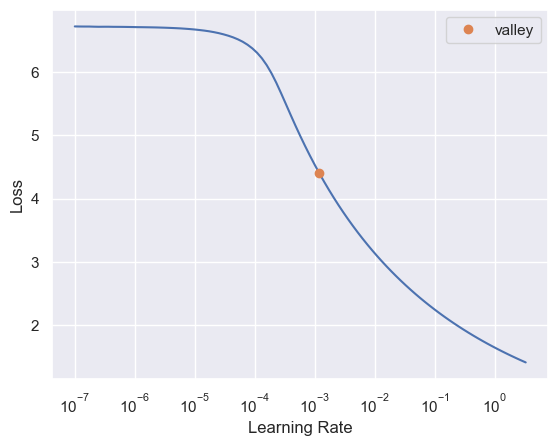

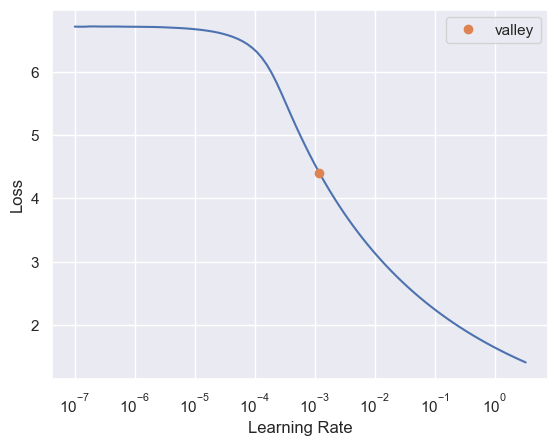

In [91]:
learn_col_res, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Colon',
    model_func=transfer_resnet_34,
    num_epochs=5
)

#### Few-shots for Colon cancer ResNet34

In [94]:
learn_few_rescol, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Colon',
    model_func=transfer_resnet_34,
    pretrained_learner=learn_col_res,
    num_epochs=5
)


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Few-shot training on: ['colon_bnt'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000494,0.000463,1.000000,1.000000,1.000000,1.000000,00:03
1,0.000393,0.000214,1.000000,1.000000,1.000000,1.000000,00:03
2,0.000307,0.000154,1.000000,1.000000,1.000000,1.000000,00:03
3,0.000250,0.000137,1.000000,1.000000,1.000000,1.000000,00:03
4,0.000213,0.000132,1.000000,1.000000,1.000000,1.000000,00:03



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0001, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Internal Transfer - vision transformer: ViT_B_16 base ViT model

In [58]:
def transfer_vit_b16(num_classes):
    model = models.vit_b_16(weights=None)  # Loading the model to be tried
    num_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(    # Replacing the classifier head with a custom classifier head
        nn.Linear(num_features, 512),    # Fully connected dense layer to reduce dimensionality
        nn.BatchNorm1d(512),             # Stabilizes by normalizing activations from each batch during training
        nn.ReLU(),                       # Adding non-linearity
        nn.Dropout(0.5),                 # Randomly setting 50% neurons to 0
        nn.Linear(512, 256),       
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )

    return model

#### Zero-shot for Lung cancer using vit_b_16


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Training on: lung_aca
Zero-shot testing on: ['lung_bnt', 'lung_scc']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 5.79e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.264891,0.048471,1.000000,1.000000,1.000000,1.000000,01:19
1,0.034120,0.001617,1.000000,1.000000,1.000000,1.000000,01:21
2,0.007135,0.006253,1.000000,1.000000,1.000000,1.000000,01:27
3,0.002963,0.004191,1.000000,1.000000,1.000000,1.000000,01:24
4,0.002037,0.003928,1.000000,1.000000,1.000000,1.000000,01:24



Zero-shot results on ['lung_bnt', 'lung_scc']:
Loss: 3.2943, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


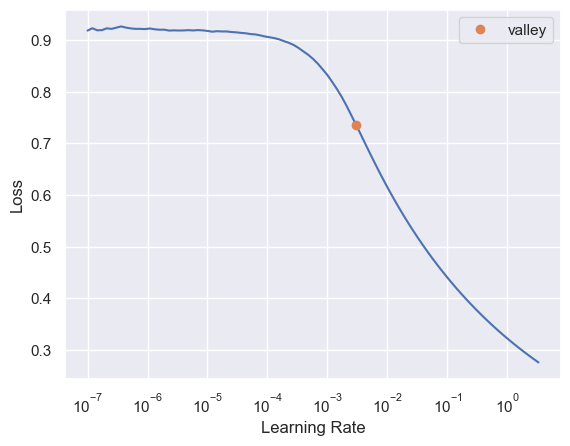

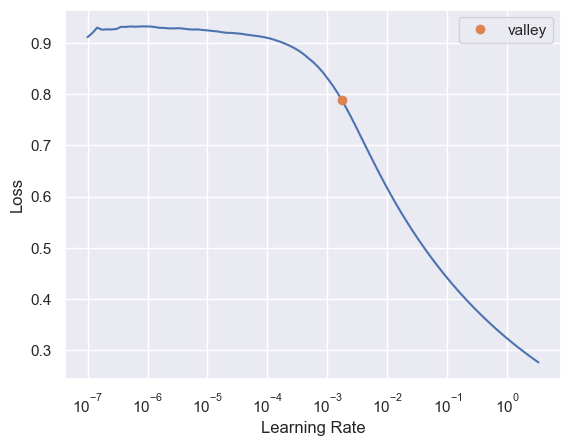

In [61]:
learn_vision, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lung',
    model_func=transfer_vit_b16,
    num_epochs=5
)

#### Few-shots for Lung cancer using vit_b_16

In [64]:
learn_few_2, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lung',
    model_func=transfer_vit_b16,
    pretrained_learner=learn_vision,
    num_epochs=5
)


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Few-shot training on: ['lung_bnt', 'lung_scc'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,3.000637,3.322245,0.510000,0.255000,0.500000,0.337748,00:08
1,1.863504,1.466364,0.510000,0.255000,0.500000,0.337748,00:08
2,1.153295,0.179809,1.000000,1.000000,1.000000,1.000000,00:08
3,0.772429,0.200515,1.000000,1.000000,1.000000,1.000000,00:08
4,0.568083,0.196846,1.000000,1.000000,1.000000,1.000000,00:08



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.2237, Acc: 0.9876, Precision: 0.9876, Recall: 0.9877, F1: 0.9876


#### Zero-shot for Lymphoma using vit_b_16


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Training on: lymph_cll
Zero-shot testing on: ['lymph_fl', 'lymph_mcl']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 4.82e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.291990,0.023304,1.000000,1.000000,1.000000,1.000000,01:22
1,0.039949,0.009611,1.000000,1.000000,1.000000,1.000000,01:21
2,0.008740,0.006928,1.000000,1.000000,1.000000,1.000000,01:19
3,0.003666,0.006165,1.000000,1.000000,1.000000,1.000000,01:19
4,0.002731,0.005590,1.000000,1.000000,1.000000,1.000000,01:18



Zero-shot results on ['lymph_fl', 'lymph_mcl']:
Loss: 3.0118, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


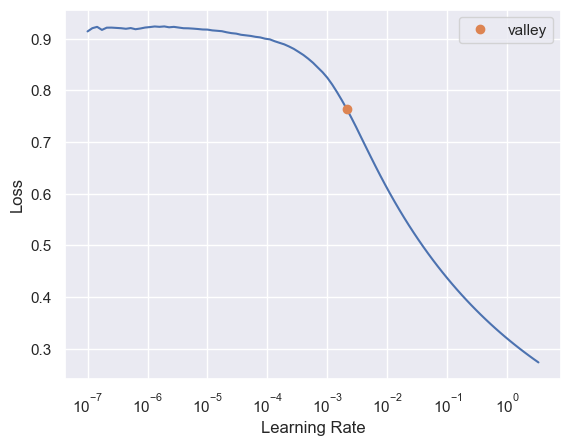

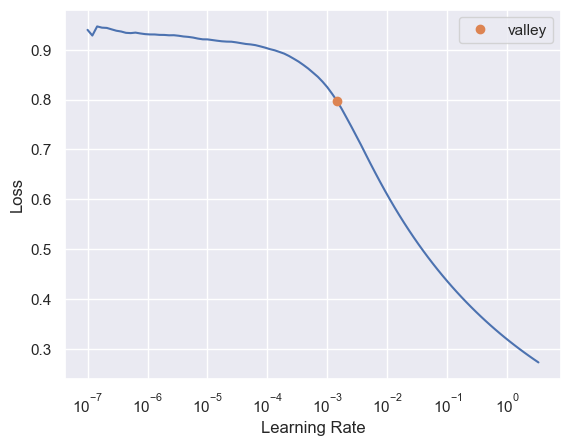

In [67]:
learn_vision_lymph, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_vit_b16,
    num_epochs=5
)

#### Few-shots for Lymphoma using vit_b_16

In [70]:
learn_few_vislym, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_vit_b16,
    pretrained_learner=learn_vision_lymph,
    num_epochs=5
)


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Few-shot training on: ['lymph_fl', 'lymph_mcl'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,3.050559,3.766333,0.510000,0.255000,0.500000,0.337748,00:09
1,2.522640,1.809214,0.490000,0.245000,0.500000,0.328859,00:08
2,2.216725,2.922629,0.510000,0.255000,0.500000,0.337748,00:08
3,2.079418,1.472978,0.700000,0.814815,0.693878,0.665775,00:08
4,1.939940,1.398678,0.780000,0.834871,0.775910,0.768810,00:08



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 1.4501, Acc: 0.7204, Precision: 0.7699, Recall: 0.7181, F1: 0.7055


#### Zero-shot for Breast cancer using vit_b_16


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Training on: breast_benign
Zero-shot testing on: ['breast_malignant']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 5.79e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.171141,0.043074,1.000000,1.000000,1.000000,1.000000,01:16
1,0.022576,0.018237,1.000000,1.000000,1.000000,1.000000,01:17
2,0.004605,0.005049,1.000000,1.000000,1.000000,1.000000,01:22
3,0.002088,0.003502,1.000000,1.000000,1.000000,1.000000,01:20
4,0.001464,0.002703,1.000000,1.000000,1.000000,1.000000,01:20



Zero-shot results on ['breast_malignant']:
Loss: 0.0025, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


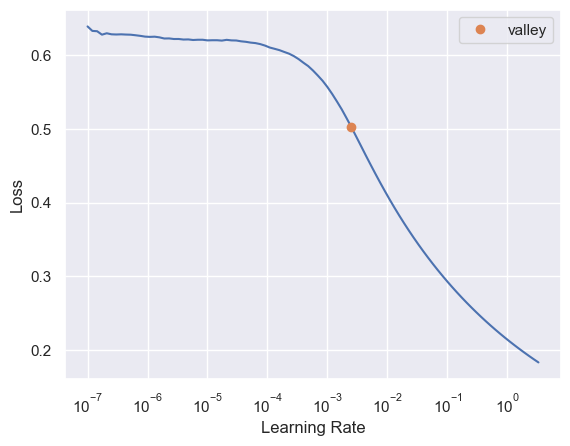

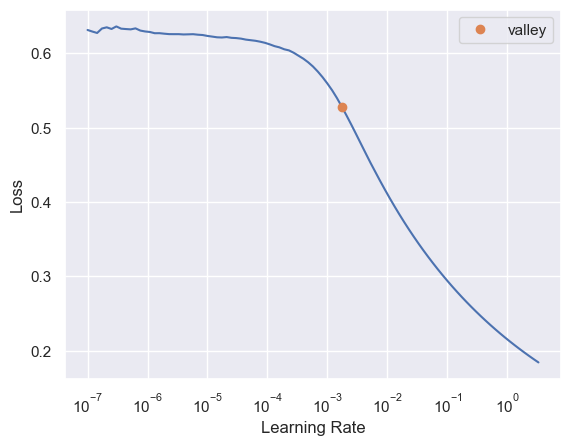

In [60]:
learn_vision_breast, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Breast',
    model_func=transfer_vit_b16,
    num_epochs=5
)

#### Few-shots for Breast using vit_b_16

In [63]:
learn_few_visbre, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Breast',
    model_func=transfer_vit_b16,
    pretrained_learner=learn_vision_breast,
    num_epochs=5
)


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Few-shot training on: ['breast_malignant'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.001537,0.003201,1.000000,1.000000,1.000000,1.000000,00:05
1,0.001375,0.002783,1.000000,1.000000,1.000000,1.000000,00:04
2,0.001214,0.002315,1.000000,1.000000,1.000000,1.000000,00:04
3,0.001118,0.002256,1.000000,1.000000,1.000000,1.000000,00:04
4,0.001070,0.002378,1.000000,1.000000,1.000000,1.000000,00:04



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0024, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot for Oral cancer using vit_b_16


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Training on: oral_normal
Zero-shot testing on: ['oral_scc']
Train samples: 5001, Test samples: 5001

Augmentation Analysis:
Original images: 4001
Images processed per epoch: 4001
Total augmented views over 5 epochs: 20005


Train set learning rate: 8.37e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.120087,0.052607,1.000000,1.000000,1.000000,1.000000,01:16
1,0.014447,0.007383,1.000000,1.000000,1.000000,1.000000,01:15
2,0.002968,0.003296,1.000000,1.000000,1.000000,1.000000,01:25
3,0.001273,0.002078,1.000000,1.000000,1.000000,1.000000,01:22
4,0.001000,0.001894,1.000000,1.000000,1.000000,1.000000,01:19



Zero-shot results on ['oral_scc']:
Loss: 0.0017, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


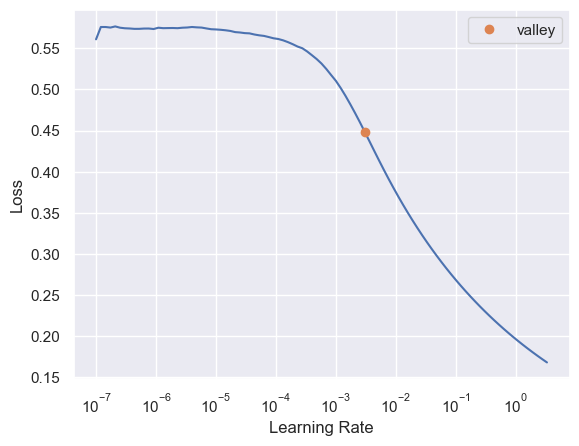

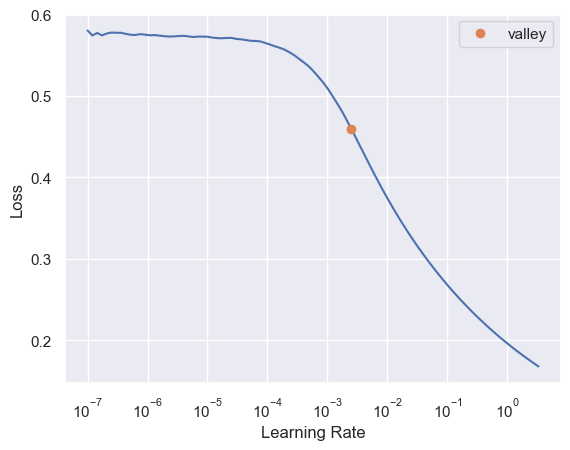

In [66]:
learn_vision_oral, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Oral',
    model_func=transfer_vit_b16,
    num_epochs=5
)

#### Few-shots for Oral using vit_b_16

In [68]:
learn_few_visor, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Oral',
    model_func=transfer_vit_b16,
    pretrained_learner=learn_vision_oral,
    num_epochs=5
)


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Few-shot training on: ['oral_scc'] (5% of data)
Few-shot samples: 250, Holdout samples: 4751

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.001190,0.002257,1.000000,1.000000,1.000000,1.000000,00:04
1,0.001040,0.001895,1.000000,1.000000,1.000000,1.000000,00:04
2,0.000903,0.001511,1.000000,1.000000,1.000000,1.000000,00:04
3,0.000824,0.001626,1.000000,1.000000,1.000000,1.000000,00:04
4,0.000773,0.001546,1.000000,1.000000,1.000000,1.000000,00:03



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0014, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot for Colon cancer using vit_b_16


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Training on: colon_aca
Zero-shot testing on: ['colon_bnt']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 1.01e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.117684,0.004220,1.000000,1.000000,1.000000,1.000000,01:17
1,0.013576,0.007435,1.000000,1.000000,1.000000,1.000000,01:18
2,0.002690,0.003204,1.000000,1.000000,1.000000,1.000000,01:22
3,0.001170,0.001979,1.000000,1.000000,1.000000,1.000000,01:21
4,0.000856,0.001608,1.000000,1.000000,1.000000,1.000000,01:15



Zero-shot results on ['colon_bnt']:
Loss: 0.0018, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


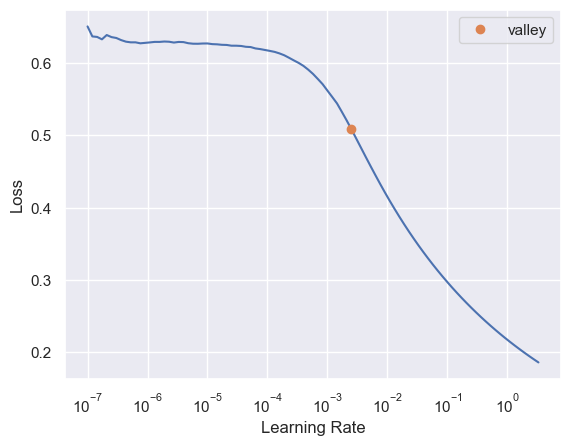

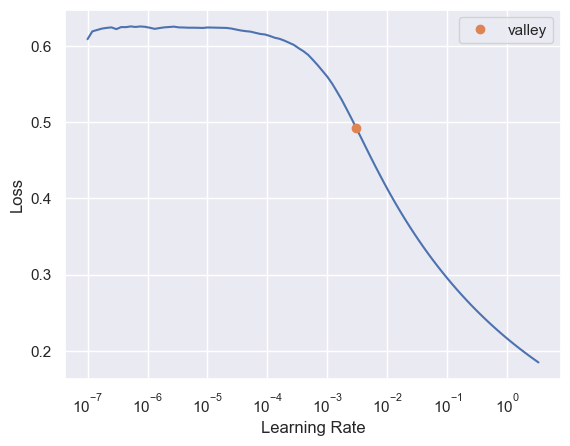

In [60]:
learn_vision_colon, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Colon',
    model_func=transfer_vit_b16,
    num_epochs=5
)

#### Few-shots for Colon using vit_b_16

In [63]:
learn_few_viscol, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Colon',
    model_func=transfer_vit_b16,
    pretrained_learner=learn_vision_colon,
    num_epochs=5
)


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Few-shot training on: ['colon_bnt'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000925,0.001824,1.000000,1.000000,1.000000,1.000000,00:04
1,0.000827,0.002077,1.000000,1.000000,1.000000,1.000000,00:03
2,0.000710,0.001249,1.000000,1.000000,1.000000,1.000000,00:04
3,0.000640,0.001261,1.000000,1.000000,1.000000,1.000000,00:04
4,0.000589,0.001207,1.000000,1.000000,1.000000,1.000000,00:04



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0013, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Internal Transfer - Trying the DeiT (Data efficient image transformer) model

In [65]:
def transfer_deit(num_classes):
    model = timm.create_model('deit_small_patch16_224', pretrained=False)  # Loading the model to be tried
    num_features = model.head.in_features # Getting the number of features from the final layer
    model.head = nn.Sequential(    # Replacing the classifier head with a custom classifier head
        nn.Linear(num_features, 512),    # Fully connected dense layer to reduce dimensionality
        nn.BatchNorm1d(512),             # Stabilizes by normalizing activations from each batch during training
        nn.ReLU(),                       # Adding non-linearity
        nn.Dropout(0.5),                 # Randomly setting 50% neurons to 0
        nn.Linear(512, 256),       
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )

    return model

#### Zero-shot for Lung cancer using DeiT small_patch16


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Training on: lung_aca
Zero-shot testing on: ['lung_bnt', 'lung_scc']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 1.01e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.174694,0.011213,1.000000,1.000000,1.000000,1.000000,00:52
1,0.019281,0.007625,1.000000,1.000000,1.000000,1.000000,00:52
2,0.003629,0.003671,1.000000,1.000000,1.000000,1.000000,00:53
3,0.001347,0.002358,1.000000,1.000000,1.000000,1.000000,00:50
4,0.000878,0.002136,1.000000,1.000000,1.000000,1.000000,00:53



Zero-shot results on ['lung_bnt', 'lung_scc']:
Loss: 3.4698, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


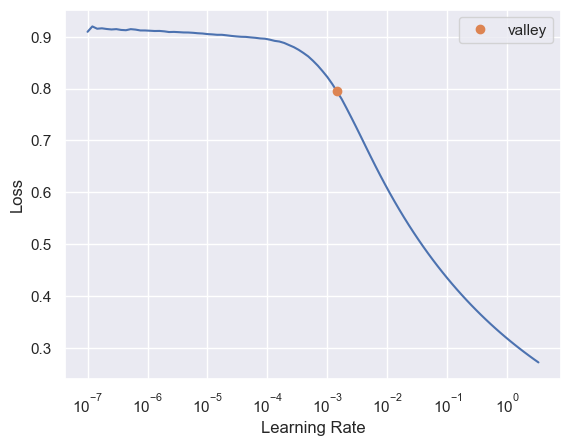

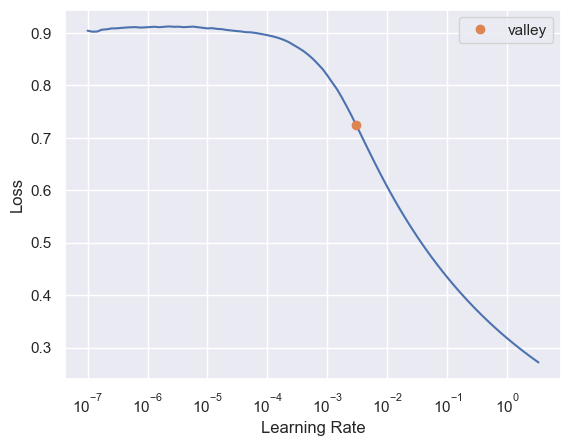

In [76]:
learn_deit, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lung',
    model_func=transfer_deit,
    num_epochs=5
)

#### Few-shots for Lung cancer using DeiT small_patch16

In [79]:
learn_few_3, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lung',
    model_func=transfer_deit,
    pretrained_learner=learn_deit,
    num_epochs=5
)


Cancer Type: Lung
Available sub-classes: ['lung_aca', 'lung_bnt', 'lung_scc']
Few-shot training on: ['lung_bnt', 'lung_scc'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,3.150344,2.863571,0.510000,0.255000,0.500000,0.337748,00:07
1,2.018374,0.818542,0.580000,0.774194,0.571429,0.479167,00:06
2,1.316628,0.138438,0.990000,0.990000,0.990196,0.989999,00:06
3,0.930076,0.279189,0.990000,0.990000,0.990196,0.989999,00:06
4,0.691540,0.306927,0.990000,0.990000,0.990196,0.989999,00:06



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.3217, Acc: 0.9754, Precision: 0.9758, Recall: 0.9756, F1: 0.9754


#### Zero-shot for Colon cancer using DeiT small_patch16


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Training on: colon_aca
Zero-shot testing on: ['colon_bnt']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 1.01e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.153989,0.009271,1.000000,1.000000,1.000000,1.000000,00:50
1,0.017340,0.005903,1.000000,1.000000,1.000000,1.000000,00:51
2,0.003383,0.002871,1.000000,1.000000,1.000000,1.000000,00:49
3,0.001469,0.002395,1.000000,1.000000,1.000000,1.000000,00:47
4,0.001094,0.001946,1.000000,1.000000,1.000000,1.000000,00:48



Zero-shot results on ['colon_bnt']:
Loss: 0.0020, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


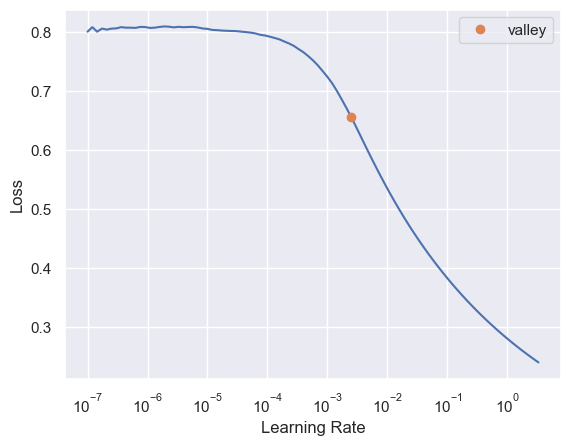

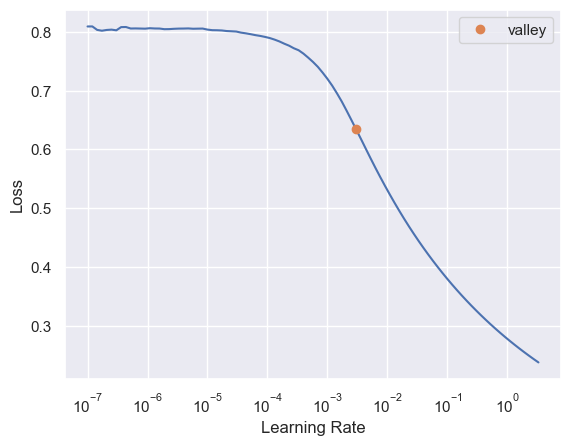

In [117]:
learn_deit_1, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Colon',
    model_func=transfer_deit,
    num_epochs=5
)

#### Few shots for Colon cancer using DeiT small_patch16

In [121]:
learn_few_4, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Colon',
    model_func=transfer_deit,
    pretrained_learner=learn_deit_1,
    num_epochs=5
)


Cancer Type: Colon
Available sub-classes: ['colon_aca', 'colon_bnt']
Few-shot training on: ['colon_bnt'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000988,0.002222,1.000000,1.000000,1.000000,1.000000,00:03
1,0.000935,0.001632,1.000000,1.000000,1.000000,1.000000,00:02
2,0.000844,0.001603,1.000000,1.000000,1.000000,1.000000,00:02
3,0.000761,0.001041,1.000000,1.000000,1.000000,1.000000,00:03
4,0.000727,0.001070,1.000000,1.000000,1.000000,1.000000,00:03



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0014, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot for Lymphoma using DeiT


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Training on: lymph_cll
Zero-shot testing on: ['lymph_fl', 'lymph_mcl']
Train samples: 5000, Test samples: 10000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 5.79e-04

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.258165,0.087146,1.000000,1.000000,1.000000,1.000000,00:55
1,0.032905,0.012524,1.000000,1.000000,1.000000,1.000000,00:53
2,0.006964,0.006354,1.000000,1.000000,1.000000,1.000000,00:54
3,0.003022,0.003929,1.000000,1.000000,1.000000,1.000000,00:54
4,0.002108,0.003647,1.000000,1.000000,1.000000,1.000000,00:54



Zero-shot results on ['lymph_fl', 'lymph_mcl']:
Loss: 3.1860, Accuracy: 0.5050, Precision: 0.2525, Recall: 0.5000, F1: 0.3355


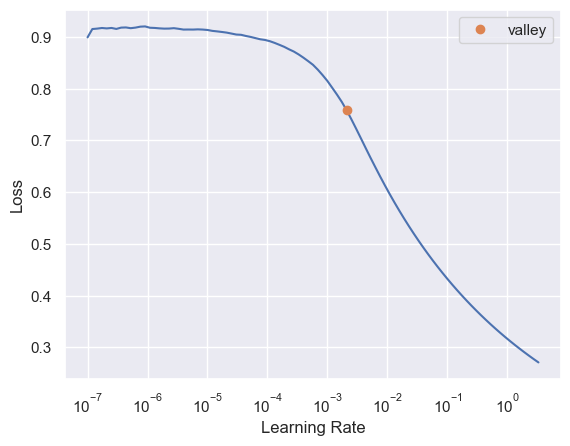

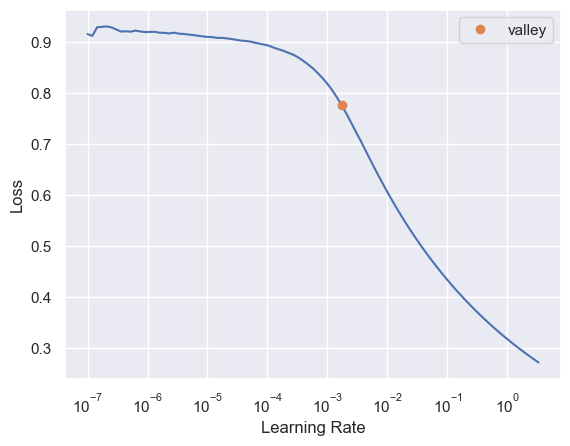

In [83]:
learn_deit_2, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_deit,
    num_epochs=5
)

#### Few-shots for Lymphoma using DeiT

In [86]:
learn_few_5, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Lymphoma',
    model_func=transfer_deit,
    pretrained_learner=learn_deit_2,
    num_epochs=5
)


Cancer Type: Lymphoma
Available sub-classes: ['lymph_cll', 'lymph_fl', 'lymph_mcl']
Few-shot training on: ['lymph_fl', 'lymph_mcl'] (5% of data)
Few-shot samples: 500, Holdout samples: 9500

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,3.312997,2.553687,0.510000,0.255000,0.500000,0.337748,00:06
1,2.774285,2.575092,0.510000,0.255000,0.500000,0.337748,00:06
2,2.418422,2.733499,0.510000,0.255000,0.500000,0.337748,00:06
3,2.218226,0.921854,0.750000,0.835526,0.744898,0.730342,00:06
4,2.017859,1.945078,0.510000,0.255000,0.500000,0.337748,00:06



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 2.0664, Acc: 0.5054, Precision: 0.2527, Recall: 0.5000, F1: 0.3357


#### Zero-shot for Breast cancer using DeiT


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Training on: breast_benign
Zero-shot testing on: ['breast_malignant']
Train samples: 5000, Test samples: 5000

Augmentation Analysis:
Original images: 4000
Images processed per epoch: 4000
Total augmented views over 5 epochs: 20000


Train set learning rate: 1.01e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.148283,0.065927,1.000000,1.000000,1.000000,1.000000,00:51
1,0.016795,0.006637,1.000000,1.000000,1.000000,1.000000,00:49
2,0.002967,0.003515,1.000000,1.000000,1.000000,1.000000,00:50
3,0.001128,0.002045,1.000000,1.000000,1.000000,1.000000,00:49
4,0.000765,0.001754,1.000000,1.000000,1.000000,1.000000,00:49



Zero-shot results on ['breast_malignant']:
Loss: 0.0016, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


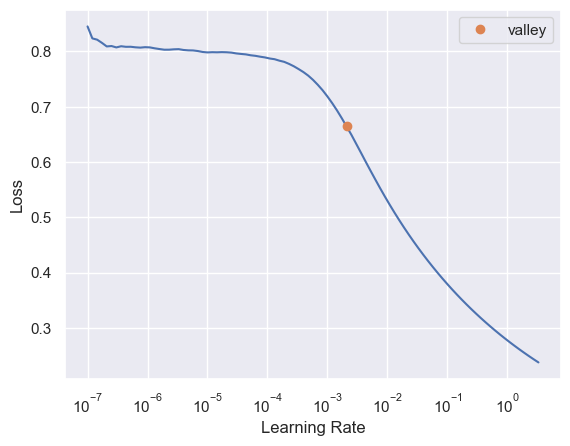

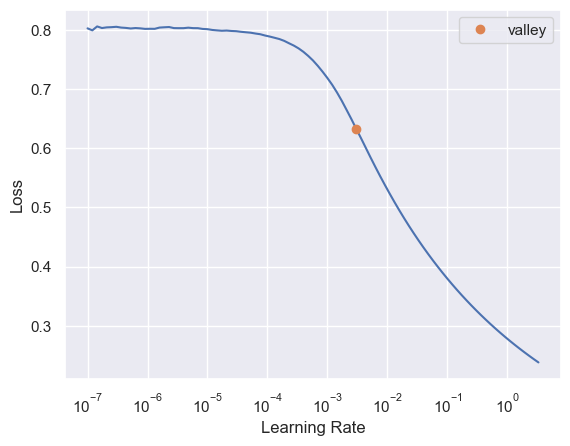

In [73]:
learn_deit_bre, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Breast',
    model_func=transfer_deit,
    num_epochs=5
)

#### Few-shots for Breast cancer using DeiT

In [76]:
learn_few_deitbre, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Breast',
    model_func=transfer_deit,
    pretrained_learner=learn_deit_bre,
    num_epochs=5
)


Cancer Type: Breast
Available sub-classes: ['breast_benign', 'breast_malignant']
Few-shot training on: ['breast_malignant'] (5% of data)
Few-shot samples: 250, Holdout samples: 4750

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.000790,0.001896,1.000000,1.000000,1.000000,1.000000,00:04
1,0.000716,0.001853,1.000000,1.000000,1.000000,1.000000,00:03
2,0.000617,0.001417,1.000000,1.000000,1.000000,1.000000,00:03
3,0.000583,0.001332,1.000000,1.000000,1.000000,1.000000,00:04
4,0.000579,0.001430,1.000000,1.000000,1.000000,1.000000,00:03



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0015, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


#### Zero-shot for Oral cancer using DeiT


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Training on: oral_normal
Zero-shot testing on: ['oral_scc']
Train samples: 5001, Test samples: 5001

Augmentation Analysis:
Original images: 4001
Images processed per epoch: 4001
Total augmented views over 5 epochs: 20005


Train set learning rate: 1.21e-03

 Starting training...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.130613,0.025912,1.000000,1.000000,1.000000,1.000000,00:50
1,0.014137,0.006446,1.000000,1.000000,1.000000,1.000000,00:49
2,0.002606,0.002390,1.000000,1.000000,1.000000,1.000000,00:48
3,0.001040,0.001564,1.000000,1.000000,1.000000,1.000000,00:47
4,0.000772,0.001451,1.000000,1.000000,1.000000,1.000000,00:48



Zero-shot results on ['oral_scc']:
Loss: 0.0012, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


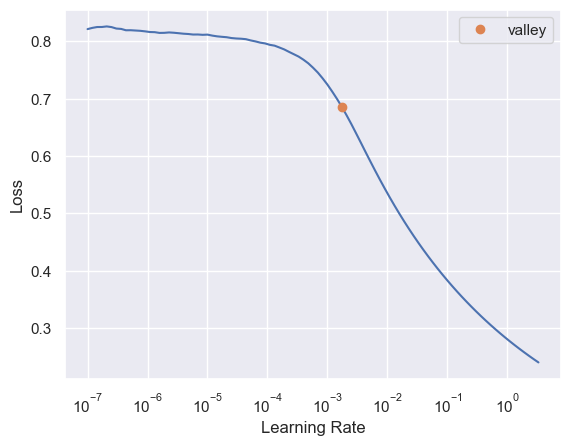

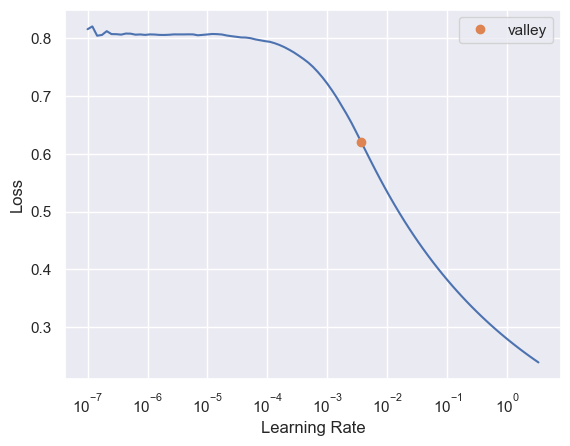

In [79]:
learn_deit_or, results, train_subclass, test_subclasses = internal_transfer_learning(
    df=df,
    target_type='Oral',
    model_func=transfer_deit,
    num_epochs=5
)

#### Few-shots for Oral cancer using DeiT

In [82]:
learn_few_deitor, few_results, few_df, holdout_df = few_shots_training(
    df=df,
    target_type='Oral',
    model_func=transfer_deit,
    pretrained_learner=learn_deit_or,
    num_epochs=5
)


Cancer Type: Oral
Available sub-classes: ['oral_normal', 'oral_scc']
Few-shot training on: ['oral_scc'] (5% of data)
Few-shot samples: 250, Holdout samples: 4751

Starting few-shot fine-tuning...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.001044,0.002033,1.000000,1.000000,1.000000,1.000000,00:03
1,0.000890,0.001349,1.000000,1.000000,1.000000,1.000000,00:03
2,0.000774,0.001539,1.000000,1.000000,1.000000,1.000000,00:03
3,0.000715,0.001457,1.000000,1.000000,1.000000,1.000000,00:03
4,0.000666,0.001279,1.000000,1.000000,1.000000,1.000000,00:03



Evaluating on holdout (unseen 95%)...



Few-shot Results on unseen 95%:
Loss: 0.0011, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


In [6]:
#%load_ext tensorboard
#%tensorboard --logdir=runs/dataset_eda